# TCC — Modelagem Preditiva: ENEM × SISU
## Mulheres na liderança em tecnologia — recorte de gênero e raça

---

### Arquitetura de dados

| Base | Período | Uso |
|------|---------|-----|
| ENEM unificado | **2021–2023** (modelos) + **2018–2023** (série temporal) | Modelo 1, Modelo 7.2, EDA racial |
| SISU consolidado | **2023** | Modelo 2, Modelo 7.1, folga de nota |

### Decisões metodológicas documentadas

- **2021–2023 para modelos:** socioeconômico completo e comparável disponível apenas a partir de 2021 (`Q007`/`Q006`/`Q023`)
- **2018–2023 para série temporal:** necessário para medir evolução do gap racial
- **Filtro conclusão EM:** mantém candidatas que concluíram o EM até 3 anos antes da prova (alinhado a Dantas et al., 2025)
- **Apenas mulheres:** recorte central do TCC — modelo para homens feito como análise comparativa (7.3)


## Seção 0 — Instalações e imports

In [ ]:
!pip install imbalanced-learn -q

In [ ]:
import os, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    f1_score, mean_absolute_error, r2_score, confusion_matrix
)
from matplotlib.patches import Patch
from imblearn.over_sampling import SMOTE

# ── Estilo visual TCC (igual ao notebook RAIS/Censo) ──────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COR_FEM    = '#2E6E8E'   # azul TCC — feminino
COR_MASC   = '#b0b0b0'   # cinza TCC — masculino
COR_NEGRA  = '#2B4C7E'   # azul escuro — negras
COR_BRANCA = '#a8c8d8'   # azul claro — brancas
COR_POS    = '#2E6E8E'   # coef positivo
COR_NEG    = '#c0392b'   # coef negativo / alerta
COR_PARDA  = '#5a8fa8'   # intermediário

FONTE_ENEM = 'Fonte: INEP. Microdados ENEM 2021–2023. Brasília.'
FONTE_SISU = 'Fonte: MEC/SESu. SISU 2023. Brasília.'

def fmt_mil(x, _):
    return f'{int(x):,}'.replace(',', '.')

def save_fig(fname, tight=True):
    if tight:
        plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✅ Salvo: {fname}')

# ── Mapas globais ──────────────────────────────────────────────────────────
REGIOES = {
    'AC':'N','AM':'N','AP':'N','PA':'N','RO':'N','RR':'N','TO':'N',
    'AL':'NE','BA':'NE','CE':'NE','MA':'NE','PB':'NE','PE':'NE',
    'PI':'NE','RN':'NE','SE':'NE',
    'DF':'CO','GO':'CO','MS':'CO','MT':'CO',
    'ES':'SE','MG':'SE','RJ':'SE','SP':'SE',
    'PR':'S','RS':'S','SC':'S'
}

renda_ord = ['Nenhuma','Até 1SM','1-2SM','2-3SM','3-4SM','4-5SM','5-6SM','6SM+']

# ── Dicionário de cursos tech (revisado — 38 cursos) ──────────────────────
CURSOS_TECH = {
    'CIÊNCIA DA COMPUTAÇÃO','CIÊNCIAS DA COMPUTAÇÃO','ABI - CIÊNCIA DA COMPUTAÇÃO',
    'SISTEMAS DE INFORMAÇÃO','SISTEMA DE INFORMAÇÃO',
    'ANÁLISE E DESENVOLVIMENTO DE SISTEMAS',
    'ENGENHARIA DE COMPUTAÇÃO','ENGENHARIA DA COMPUTAÇÃO','ENGENHARIA COMPUTACIONAL',
    'ENGENHARIA DE COMPUTAÇÃO E INFORMAÇÃO','ENGENHARIA ELETRÔNICA E DE COMPUTAÇÃO',
    'ENGENHARIA DE SOFTWARE','ENGENHARIA DE SISTEMAS',
    'REDES DE COMPUTADORES','SISTEMAS DE TELECOMUNICAÇÕES','SISTEMAS PARA INTERNET',
    'SISTEMAS E MÍDIAS DIGITAIS','COMPUTAÇÃO','COMPUTAÇÃO E INFORMÁTICA',
    'JOGOS DIGITAIS','DESIGN DE JOGOS','SEGURANÇA DA INFORMAÇÃO',
    'GESTÃO DE DADOS','GESTÃO DA TECNOLOGIA DA INFORMAÇÃO',
    'TECNOLOGIA DA INFORMAÇÃO','TECNOLOGIAS DA INFORMAÇÃO E COMUNICAÇÃO',
    'TELEMÁTICA','GEOPROCESSAMENTO','INFORMÁTICA',
    'INTELIGÊNCIA ARTIFICIAL',
    'CIÊNCIA DE DADOS','CIÊNCIA DE DADOS E INTELIGÊNCIA ARTIFICIAL',
    'CIÊNCIA DE DADOS PARA NEGÓCIOS','CIÊNCIA DOS DADOS',
    'MATEMÁTICA COMPUTACIONAL','MATEMÁTICA APLICADA E COMPUTACIONAL',
    'INTERDISCIPLINAR EM TECNOLOGIA DA INFORMAÇÃO - BI/LI',
    'INTERDISCIPLINAR EM MATEMÁTICA E COMPUTAÇÃO E SUAS TECNOLOGIAS',
}
print(f'Imports OK | CURSOS_TECH: {len(CURSOS_TECH)} cursos')


Imports OK | CURSOS_TECH: 38 cursos


## Seção 1 — Bases de dados

### 1.1 — Caminhos dos arquivos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PASTA = '/content/drive/MyDrive/TCC/'

# ENEM — todos os anos disponíveis (2018–2023)
ANOS_ENEM = {
    2018: PASTA + 'MICRODADOS_ENEM_2018.csv',
    2019: PASTA + 'MICRODADOS_ENEM_2019.csv',
    2020: PASTA + 'MICRODADOS_ENEM_2020.csv',
    2021: PASTA + 'MICRODADOS_ENEM_2021.csv',
    2022: PASTA + 'MICRODADOS_ENEM_2022.csv',
    2023: PASTA + 'MICRODADOS_ENEM_2023.csv',
}

# SISU 2023
PATH_SISU        = PASTA + 'sisu_2023_mulheres.csv'
SISU_JA_FILTRADO = True   # True = base consolidada do preparar_sisu_2023.ipynb


Mounted at /content/drive


### 1.2 — Leitura do ENEM (2018–2023)

Filtros aplicados na leitura: **mulheres** (`TP_SEXO == F`), **não-treineiras** (`IN_TREINEIRO == 0`),
**presentes na prova de MT** (`TP_PRESENCA_MT == 1`).

A base resultante (`df_enem_unif`) contém **todos os anos**. As bases de análise são criadas
na Seção 2 com os filtros de período corretos para cada uso.


In [ ]:
COLS_ENEM_UNIF = [
    'NU_INSCRICAO','NU_ANO',
    'TP_SEXO','TP_COR_RACA','TP_FAIXA_ETARIA',
    'IN_TREINEIRO','TP_ST_CONCLUSAO','TP_ANO_CONCLUIU',
    'SG_UF_PROVA',
    'TP_DEPENDENCIA_ADM_ESC','TP_LOCALIZACAO_ESC',
    'TP_PRESENCA_MT',
    'NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO',
    'Q001','Q002','Q003','Q004',
    'Q006',      # renda: 2018/2019/2020/2023
    'Q007',      # renda: 2021/2022
    'Q023',      # escola EM: 2021/2022/2023
    'Q027',      # escola EM: 2018
    'TP_ESCOLA', # escola EM: 2019/2020
]

dfs_anos = []
for ano, path in ANOS_ENEM.items():
    if not os.path.exists(path):
        print(f'[AVISO] Não encontrado: {path}')
        continue
    print(f'Lendo ENEM {ano}...', end=' ')
    cols_disp = pd.read_csv(path, sep=';', encoding='latin1', nrows=0).columns.tolist()
    cols_ler  = [c for c in COLS_ENEM_UNIF if c in cols_disp]
    chunks = []
    for chunk in pd.read_csv(path, sep=';', encoding='latin1',
                              low_memory=False, usecols=cols_ler, chunksize=300_000):
        mask = (
            (chunk['TP_SEXO'] == 'F') &
            (chunk['IN_TREINEIRO'] == 0) &
            (chunk['TP_PRESENCA_MT'] == 1)
        )
        chunks.append(chunk[mask])
    df_ano = pd.concat(chunks, ignore_index=True)
    df_ano['NU_ANO'] = ano
    dfs_anos.append(df_ano)
    print(f'{len(df_ano):,} mulheres')

df_enem_unif = pd.concat(dfs_anos, ignore_index=True)
print(f'\nTotal ENEM unificado (mulheres, 2018–2023): {len(df_enem_unif):,}')
print(f'Anos: {sorted(df_enem_unif["NU_ANO"].unique())}')


Lendo ENEM 2018... 2,015,429 mulheres
Lendo ENEM 2019... 1,872,987 mulheres
Lendo ENEM 2020... 1,342,433 mulheres
Lendo ENEM 2021... 1,142,491 mulheres
Lendo ENEM 2022... 1,168,016 mulheres
Lendo ENEM 2023... 1,315,858 mulheres

Total ENEM unificado (mulheres, 2018–2023): 8,857,214
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


### 1.3 — Leitura do SISU 2023

In [ ]:
COLS_SISU = [
    'ANO','NOME_CURSO','GRAU','TURNO',
    'MOD_CONCORRENCIA','TP_COTA',
    'SEXO','DT_NASCIMENTO','UF_CANDIDATO','UF_IES',
    'NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R',
    'NOTA_CANDIDATO','NOTA_CORTE',
    'OPCAO','APROVADO','MATRICULA',
    'IDADE','REGIAO_CANDIDATA','REGIAO_IES','COTA','IS_TECH',
    'MOBILIDADE','TIPO_ARQUIVO',
]

df_sisu_raw = pd.read_csv(
    PATH_SISU,
    sep='|' if not SISU_JA_FILTRADO else ',',
    encoding='latin1' if not SISU_JA_FILTRADO else 'utf-8-sig',
    low_memory=False,
    usecols=lambda c: c in COLS_SISU
)
if not SISU_JA_FILTRADO:
    df_sisu_raw = df_sisu_raw[df_sisu_raw['SEXO'] == 'F'].copy()

print(f'SISU carregado: {df_sisu_raw.shape[0]:,} linhas × {df_sisu_raw.shape[1]} colunas')
df_sisu_raw.head(3)


SISU carregado: 385,929 linhas × 27 colunas


,ANO,UF_IES,NOME_CURSO,GRAU,TURNO,TP_COTA,MOD_CONCORRENCIA,SEXO,DT_NASCIMENTO,UF_CANDIDATO,...,NOTA_CORTE,APROVADO,MATRICULA,TIPO_ARQUIVO,IDADE,REGIAO_CANDIDATA,REGIAO_IES,MOBILIDADE,COTA,IS_TECH
0,2023,RJ,ADMINISTRAÇÃO,Bacharelado,Integral,NaN,Ampla concorrência,F,2005,RJ,...,720.87,S,EFETIVADA,Chamada Regular,18,SE,SE,0,Ampla,0
1,2023,RJ,ADMINISTRAÇÃO,Bacharelado,Integral,NaN,Ampla concorrência,F,2004,RJ,...,720.87,S,EFETIVADA,Chamada Regular,19,SE,SE,0,Ampla,0
2,2023,RJ,ADMINISTRAÇÃO,Bacharelado,Integral,PPI,"Candidatos autodeclarados pretos, pardos ou in...",F,2003,RJ,...,641.80,S,EFETIVADA,Chamada Regular,20,SE,SE,0,Cota,0


## Seção 2 — Tratamento dos dados

### 2.1 — Tratamento do ENEM

Cria **duas bases** explícitas:
- `df_enem` — **2021–2023** — usada em todos os modelos e EDA
- `df_enem_full` — **2018–2023** — usada exclusivamente na série temporal (7.4)

Critérios metodológicos alinhados com Dantas et al. (2025):
- Conclusão recente do EM (até 3 anos antes da prova)
- Renda: mapeamento condicional por ano (`Q007` em 2021/2022, `Q006` em 2023)
- Ocupação dos pais: letras A–E → grupos 1–5


In [ ]:
renda_map_letras = {
    'A':'Nenhuma','B':'Até 1SM','C':'1-2SM','D':'2-3SM',
    'E':'3-4SM','F':'4-5SM','G':'5-6SM','H':'6SM+',
    'I':'6SM+','J':'6SM+','K':'6SM+','L':'6SM+',
    'M':'6SM+','N':'6SM+','O':'6SM+','P':'6SM+','Q':'6SM+',
}
escol_map  = {'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6,'H':7}
ocup_map   = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':np.nan}
raca_map   = {0:'Não declarado',1:'Branca',2:'Preta',3:'Parda',
              4:'Amarela',5:'Indígena',6:'N/D'}

def tratar_enem(df_raw):
    df = df_raw.copy()

    # Conclusão recente do EM
    if 'TP_ANO_CONCLUIU' in df.columns:
        df['TP_ANO_CONCLUIU'] = pd.to_numeric(df['TP_ANO_CONCLUIU'], errors='coerce')
        df = df[df['TP_ANO_CONCLUIU'].isin([1,2,3,4])]

    # Raça
    df['RACA_LABEL'] = df['TP_COR_RACA'].map(raca_map)
    df['NEGRA']      = df['TP_COR_RACA'].isin([2,3]).astype(int)
    df['GRUPO_RACA'] = df['TP_COR_RACA'].map(
        {1:'Branca',2:'Negra',3:'Negra',4:'Outra',5:'Outra',0:'N/D'}
    ).fillna('N/D')

    # Renda — vetorizado por ano (sem apply linha a linha)
    df['RENDA_CAT'] = np.nan
    # 2021/2022: Q007
    mask_21_22 = df['NU_ANO'].isin([2021,2022]) & df['Q007'].notna()
    df.loc[mask_21_22, 'RENDA_CAT'] = (
        df.loc[mask_21_22, 'Q007'].astype(str).str.strip().str.upper()
        .map(renda_map_letras)
    )
    # 2018/2019/2020/2023: Q006
    mask_q006 = df['NU_ANO'].isin([2018,2019,2020,2023]) & df['Q006'].notna()
    df.loc[mask_q006, 'RENDA_CAT'] = (
        df.loc[mask_q006, 'Q006'].astype(str).str.strip().str.upper()
        .map(renda_map_letras)
    )
    df['RENDA_CAT'] = pd.Categorical(df['RENDA_CAT'], categories=renda_ord, ordered=True)
    df['RENDA_NUM'] = df['RENDA_CAT'].cat.codes.replace(-1, np.nan)

    # Escolaridade dos pais
    df['ESCOL_PAI']      = df['Q001'].map(escol_map)
    df['ESCOL_MAE']      = df['Q002'].map(escol_map)
    df['ESCOL_MAX_PAIS'] = df[['ESCOL_PAI','ESCOL_MAE']].max(axis=1)

    # Ocupação dos pais
    if 'Q003' in df.columns:
        df['OCUP_PAI'] = df['Q003'].astype(str).str.strip().str.upper().map(ocup_map)
    if 'Q004' in df.columns:
        df['OCUP_MAE'] = df['Q004'].astype(str).str.strip().str.upper().map(ocup_map)

    # Escola — vetorizado por ano
    df['TIPO_ESCOLA_Q'] = np.nan
    # 2021/2022/2023: Q023
    if 'Q023' in df.columns:
        mask_q023 = df['NU_ANO'].isin([2021,2022,2023])
        escola_q023 = df.loc[mask_q023,'Q023'].astype(str).str.strip().str.upper()
        df.loc[mask_q023,'TIPO_ESCOLA_Q'] = escola_q023.map(
            {'A':'Pública','B':'Privada','C':'Privada'}
        )
    # 2019/2020: TP_ESCOLA
    if 'TP_ESCOLA' in df.columns:
        mask_tp = df['NU_ANO'].isin([2019,2020])
        df.loc[mask_tp,'TIPO_ESCOLA_Q'] = df.loc[mask_tp,'TP_ESCOLA'].astype(str).map(
            {'2':'Pública','3':'Privada'}
        )
    # 2018: Q027
    if 'Q027' in df.columns:
        mask_q027 = df['NU_ANO'] == 2018
        df.loc[mask_q027,'TIPO_ESCOLA_Q'] = df.loc[mask_q027,'Q027'].astype(str).str.strip().str.upper().map(
            {'A':'Pública','B':'Privada','C':'Privada','D':'Privada','E':'Privada'}
        )
    df['ESCOLA_PUBLICA'] = df['TIPO_ESCOLA_Q'].map({'Pública':1,'Privada':0})

    # Região
    df['REGIAO'] = df['SG_UF_PROVA'].map(REGIOES).fillna('N/D')

    # Remove ausentes no target
    df = df[df['NU_NOTA_MT'].notna()]
    return df


# Base completa (2018–2023) — só para série temporal
df_enem_full = tratar_enem(df_enem_unif)

# Base de modelos (2021–2023) — EDA + todos os modelos
df_enem = df_enem_full[df_enem_full['NU_ANO'].isin([2021,2022,2023])].copy()

print(f'df_enem (modelos — 2021–2023):     {len(df_enem):,} linhas')
print(f'df_enem_full (série — 2018–2023):  {len(df_enem_full):,} linhas')
print(f'Anos em df_enem:      {sorted(df_enem["NU_ANO"].unique())}')
print(f'Anos em df_enem_full: {sorted(df_enem_full["NU_ANO"].unique())}')
print(f'\nNota MT — média: {df_enem["NU_NOTA_MT"].mean():.1f} | dp: {df_enem["NU_NOTA_MT"].std():.1f}')
print(f'\nDistribuição raça/cor (2021–2023):')
print(df_enem['RACA_LABEL'].value_counts())
print(f'\nDistribuição renda (2021–2023):')
print(df_enem['RENDA_CAT'].value_counts().sort_index())

# Diagnóstico de nulos por variável-chave
print(f'\nNulos nas variáveis do Modelo 1:')
for col in ['RENDA_NUM','ESCOL_MAX_PAIS','ESCOLA_PUBLICA','OCUP_PAI','OCUP_MAE']:
    if col in df_enem.columns:
        n = df_enem[col].isna().sum()
        print(f'  {col}: {n:,} ({100*n/len(df_enem):.1f}%)')


df_enem (modelos — 2021–2023):     1,164,428 linhas
df_enem_full (série — 2018–2023):  3,074,639 linhas
Anos em df_enem:      [np.int64(2021), np.int64(2022), np.int64(2023)]
Anos em df_enem_full: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Nota MT — média: 535.9 | dp: 121.5

Distribuição raça/cor (2021–2023):
RACA_LABEL
Parda            491586
Branca           483313
Preta            142369
Amarela           24392
Não declarado     17171
Indígena           5597
Name: count, dtype: int64

Distribuição renda (2021–2023):
RENDA_CAT
Nenhuma    733447
Até 1SM    167208
1-2SM       73645
2-3SM       60343
3-4SM       30163
4-5SM       16922
5-6SM       26696
6SM+        56003
Name: count, dtype: int64

Nulos nas variáveis do Modelo 1:
  RENDA_NUM: 1 (0.0%)
  ESCOL_MAX_PAIS: 1 (0.0%)
  ESCOLA_PUBLICA: 1 (0.0%)
  OCUP_PAI: 126,286 (10.8%)
  OCUP_MAE: 78,734 (6.8%)


### 2.2 — Tratamento do SISU 2023

In [ ]:
df_sisu = df_sisu_raw.copy()

if not SISU_JA_FILTRADO:
    df_sisu = df_sisu[df_sisu['OPCAO'] == 1]
    NOTAS_SISU = ['NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R','NOTA_CANDIDATO','NOTA_CORTE']
    for col in NOTAS_SISU:
        if col in df_sisu.columns:
            df_sisu[col] = pd.to_numeric(
                df_sisu[col].astype(str).str.replace(',','.', regex=False), errors='coerce')
    df_sisu['DT_NASCIMENTO'] = pd.to_numeric(df_sisu['DT_NASCIMENTO'], errors='coerce')
    df_sisu['IDADE']         = (2023 - df_sisu['DT_NASCIMENTO']).clip(15, 75)
    df_sisu['REGIAO_CANDIDATA'] = df_sisu['UF_CANDIDATO'].map(REGIOES).fillna('N/D')
    df_sisu['COTA'] = df_sisu['MOD_CONCORRENCIA'].apply(
        lambda x: 'Ampla' if str(x).lower() == 'ampla concorrência' else 'Cota')
    df_sisu['IS_TECH'] = df_sisu['NOME_CURSO'].isin(CURSOS_TECH).astype(int)
else:
    # Alias REGIAO
    if 'REGIAO_CANDIDATA' in df_sisu.columns and 'REGIAO' not in df_sisu.columns:
        df_sisu['REGIAO'] = df_sisu['REGIAO_CANDIDATA']
    elif 'UF_CANDIDATO' in df_sisu.columns:
        df_sisu['REGIAO_CANDIDATA'] = df_sisu['UF_CANDIDATO'].map(REGIOES).fillna('N/D')
        df_sisu['REGIAO'] = df_sisu['REGIAO_CANDIDATA']
    # Atualizar IS_TECH com dicionário revisado
    df_sisu['IS_TECH'] = df_sisu['NOME_CURSO'].isin(CURSOS_TECH).astype(int)

if 'REGIAO' not in df_sisu.columns and 'REGIAO_CANDIDATA' in df_sisu.columns:
    df_sisu['REGIAO'] = df_sisu['REGIAO_CANDIDATA']

n_tech = df_sisu['IS_TECH'].sum()
n_tot  = len(df_sisu)
print(f'SISU tratado (mulheres): {n_tot:,}')
print(f'  Tech:     {n_tech:,} ({n_tech/n_tot*100:.1f}%)')
print(f'  Não-tech: {n_tot-n_tech:,} ({(n_tot-n_tech)/n_tot*100:.1f}%)')
print(f'  Desbalanceamento: {(n_tot-n_tech)/n_tech:.0f}:1')
print(f'\nTop 10 cursos tech:')
print(df_sisu[df_sisu['IS_TECH']==1]['NOME_CURSO'].value_counts().head(10))


SISU tratado (mulheres): 385,929
  Tech:     13,789 (3.6%)
  Não-tech: 372,140 (96.4%)
  Desbalanceamento: 27:1

Top 10 cursos tech:
NOME_CURSO
CIÊNCIA DA COMPUTAÇÃO                    3674
ANÁLISE E DESENVOLVIMENTO DE SISTEMAS    2418
SISTEMAS DE INFORMAÇÃO                   2266
ENGENHARIA DE COMPUTAÇÃO                 1324
COMPUTAÇÃO                                569
ENGENHARIA DE SOFTWARE                    565
SISTEMAS PARA INTERNET                    393
ENGENHARIA DA COMPUTAÇÃO                  365
REDES DE COMPUTADORES                     341
SISTEMA DE INFORMAÇÃO                     274
Name: count, dtype: int64


## Seção 3 — EDA: desigualdades de gênero e raça

> **Base:** `df_enem` — 2021–2023, mulheres com notas e socioeconômico.


### 3.1 — Distribuição racial e nota MT por raça

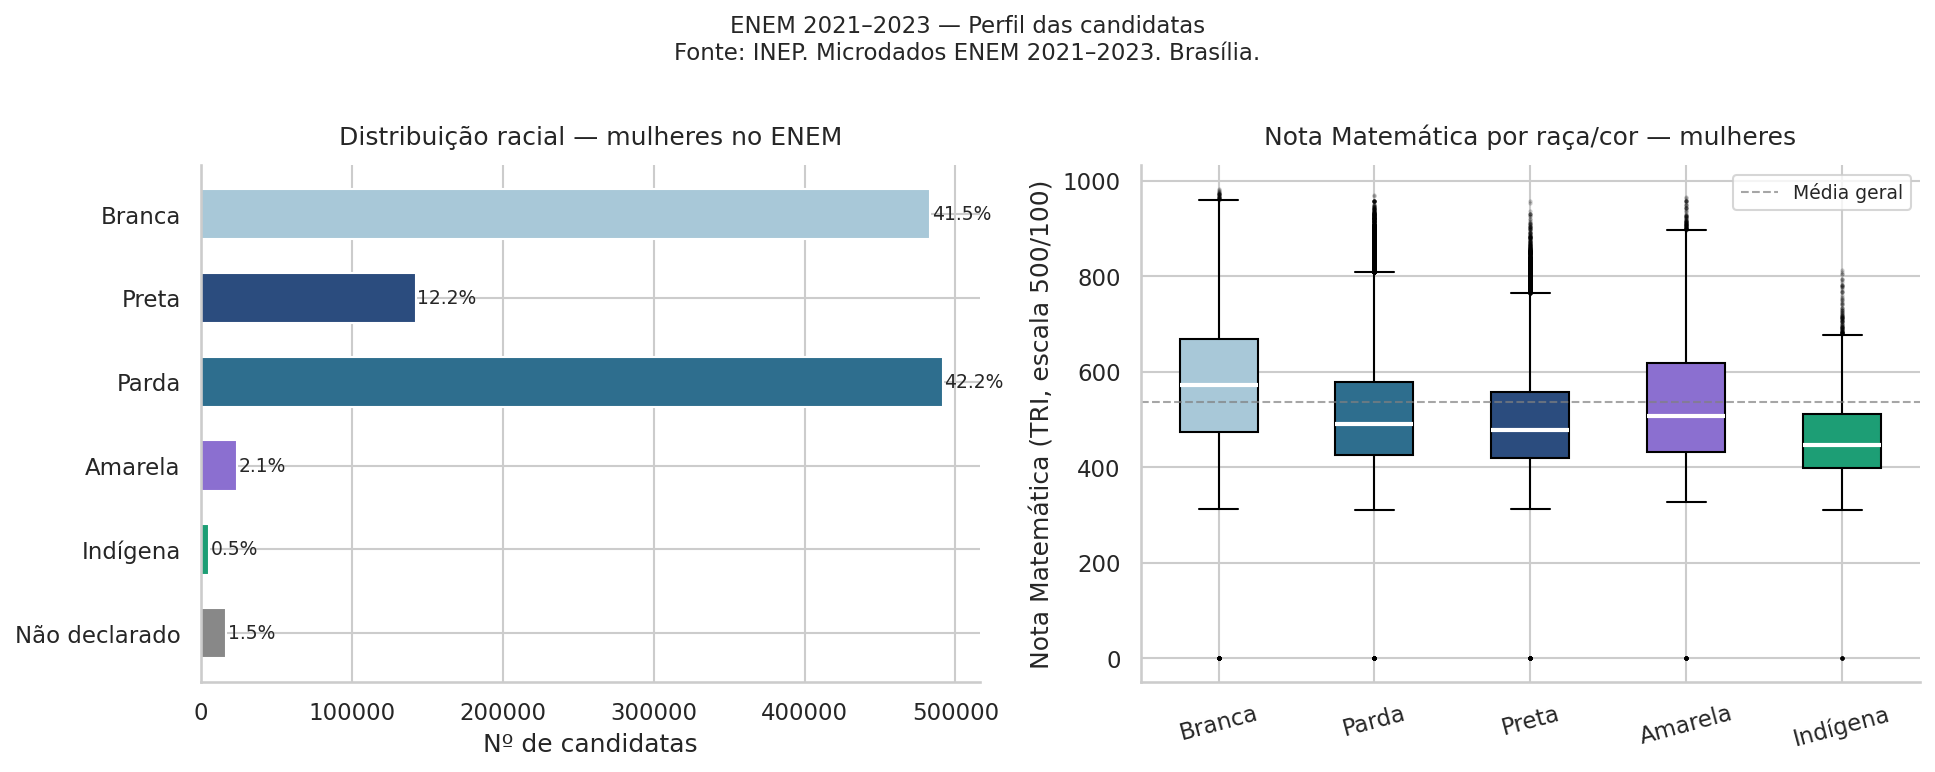

✅ Salvo: eda_raca_nota.png


In [ ]:
# BASE: df_enem (2021–2023)
ano_label = f"{min(df_enem['NU_ANO'].unique())}–{max(df_enem['NU_ANO'].unique())}"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribuição racial
ax = axes[0]
ordem_raca = ['Branca','Preta','Parda','Amarela','Indígena','Não declarado']
rc = df_enem['RACA_LABEL'].value_counts()
rc = rc.reindex([r for r in ordem_raca if r in rc.index])
cores_raca = [COR_BRANCA, COR_NEGRA, COR_FEM, '#8B6FD0', '#1D9E75', '#888888']
ax.barh(rc.index[::-1], rc.values[::-1],
        color=cores_raca[::-1], edgecolor='white', height=0.6)
ax.set_xlabel('Nº de candidatas')
ax.set_title('Distribuição racial — mulheres no ENEM', fontsize=12, pad=10)
for i, v in enumerate(rc.values[::-1]):
    ax.text(v + 1000, i, f'{v/len(df_enem)*100:.1f}%', va='center', fontsize=9)

# Boxplot nota MT por raça
ax2 = axes[1]
grupos_raca = [r for r in ['Branca','Parda','Preta','Amarela','Indígena']
               if r in df_enem['RACA_LABEL'].values]
dados_box = [df_enem[df_enem['RACA_LABEL']==r]['NU_NOTA_MT'].dropna() for r in grupos_raca]
bp = ax2.boxplot(dados_box, labels=grupos_raca, patch_artist=True,
                 medianprops={'color':'white','lw':2},
                 flierprops={'marker':'o','markersize':1,'alpha':0.2})
cores_box = [COR_BRANCA, COR_FEM, COR_NEGRA, '#8B6FD0', '#1D9E75']
for patch, cor in zip(bp['boxes'], cores_box[:len(grupos_raca)]):
    patch.set_facecolor(cor)
ax2.set_ylabel('Nota Matemática (TRI, escala 500/100)')
ax2.set_title('Nota Matemática por raça/cor — mulheres', fontsize=12, pad=10)
ax2.tick_params(axis='x', rotation=15)
ax2.axhline(df_enem['NU_NOTA_MT'].mean(), color='gray',
            linestyle='--', lw=1, alpha=0.7, label='Média geral')
ax2.legend(fontsize=9)

plt.suptitle(f'ENEM {ano_label} — Perfil das candidatas\n{FONTE_ENEM}',
             fontsize=11, y=1.02)
save_fig('eda_raca_nota.png')


### 3.2 — Nota MT por renda × raça

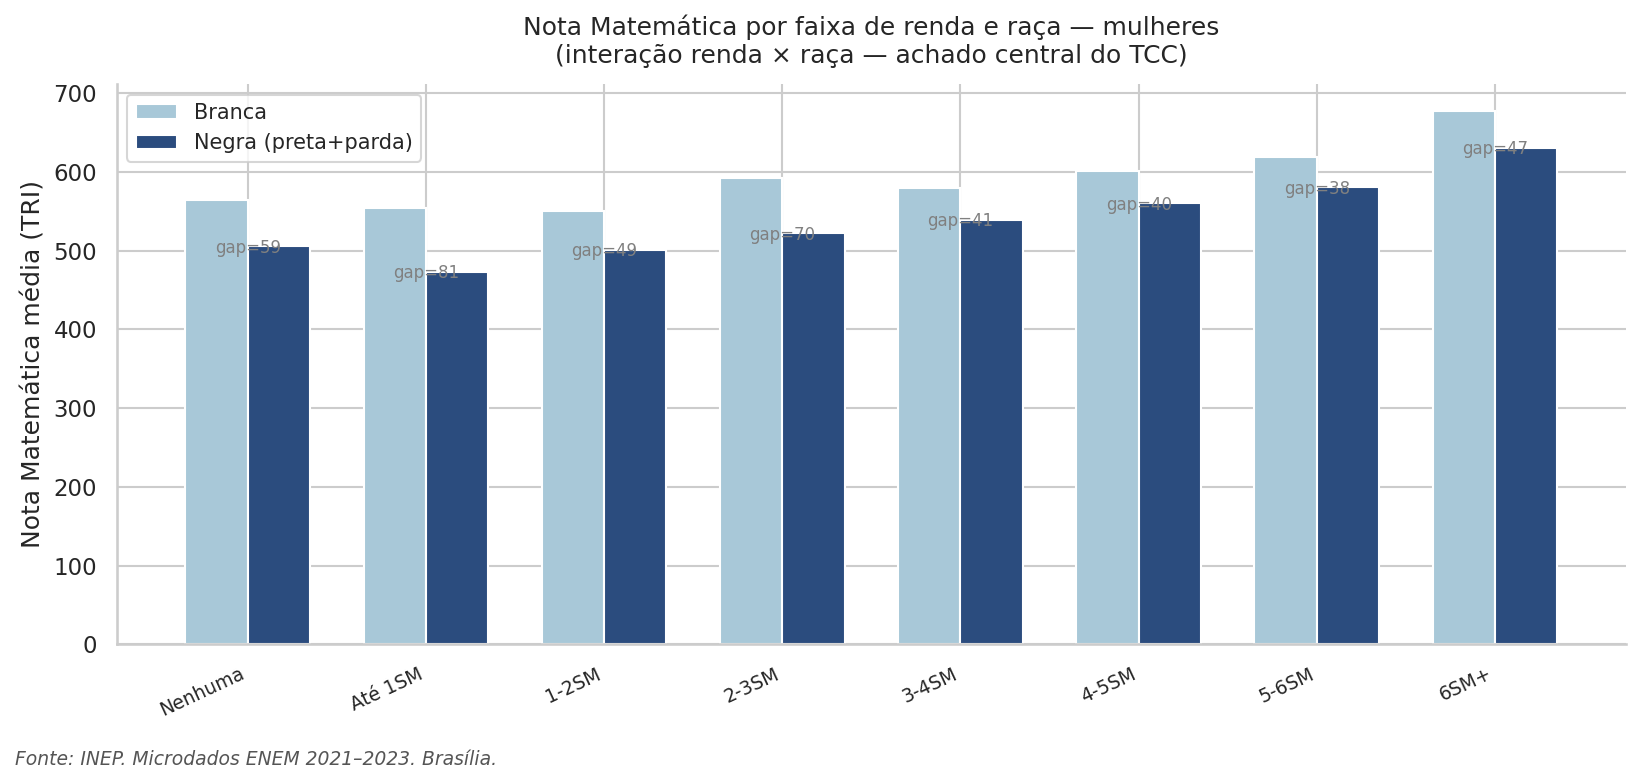

✅ Salvo: eda_renda_raca_nota.png

Tabela pivot (nota média por renda × raça):
GRUPO_RACA  Branca  Negra
RENDA_CAT                
Nenhuma      564.1  505.5
Até 1SM      554.3  473.4
1-2SM        549.8  500.5
2-3SM        591.8  521.8
3-4SM        579.6  538.7
4-5SM        600.6  560.1
5-6SM        618.2  580.4
6SM+         677.4  630.1


In [ ]:
# BASE: df_enem (2021–2023)
pivot = (df_enem[df_enem['GRUPO_RACA'].isin(['Branca','Negra'])]
         .groupby(['RENDA_CAT','GRUPO_RACA'], observed=True)['NU_NOTA_MT']
         .mean()
         .unstack('GRUPO_RACA'))

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(pivot))
w = 0.35
ax.bar([i-w/2 for i in x], pivot.get('Branca',[0]*len(pivot)),
       width=w, color=COR_BRANCA, label='Branca', edgecolor='white')
ax.bar([i+w/2 for i in x], pivot.get('Negra',[0]*len(pivot)),
       width=w, color=COR_NEGRA, label='Negra (preta+parda)', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Nota Matemática média (TRI)')
ax.set_title('Nota Matemática por faixa de renda e raça — mulheres\n'
             '(interação renda × raça — achado central do TCC)', fontsize=12, pad=10)
ax.legend(fontsize=10)
if 'Branca' in pivot.columns and 'Negra' in pivot.columns:
    for i, (renda, row) in enumerate(pivot.iterrows()):
        gap = row.get('Branca',0) - row.get('Negra',0)
        if pd.notna(gap) and gap > 0:
            ax.annotate(f'gap={gap:.0f}',
                        xy=(i, min(row.get('Branca',500), row.get('Negra',500)) - 8),
                        ha='center', fontsize=8, color='gray')
fig.text(0.01, -0.03, FONTE_ENEM, fontsize=9, color='#555555', style='italic')
save_fig('eda_renda_raca_nota.png')
print('\nTabela pivot (nota média por renda × raça):')
print(pivot.round(1).to_string())


### 3.3 — Nota MT por tipo de escola × raça

=== Nota MT por escola e raça (mulheres) ===
                           mean   count
TIPO_ESCOLA_Q GRUPO_RACA               
Privada       Branca      618.0   82502
              Negra       548.6   52234
Pública       Branca      567.3  400811
              Negra       502.3  581721


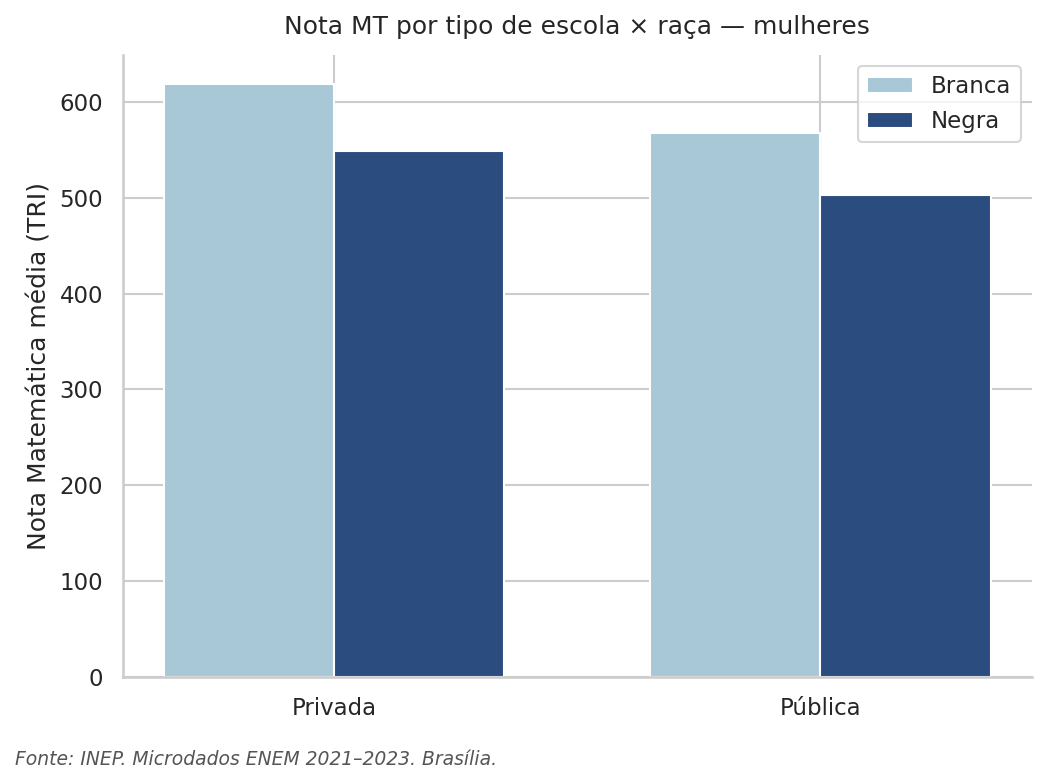

✅ Salvo: eda_escola_raca.png


In [ ]:
# BASE: df_enem (2021–2023)
escola_raca = (df_enem[df_enem['GRUPO_RACA'].isin(['Branca','Negra']) &
                       df_enem['TIPO_ESCOLA_Q'].isin(['Pública','Privada'])]
               .groupby(['TIPO_ESCOLA_Q','GRUPO_RACA'])['NU_NOTA_MT']
               .agg(['mean','count']).round(1))
print('=== Nota MT por escola e raça (mulheres) ===')
print(escola_raca.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
pivot_esc = escola_raca['mean'].unstack('GRUPO_RACA')
x = range(len(pivot_esc))
w = 0.35
ax.bar([i-w/2 for i in x], pivot_esc.get('Branca',[0]*len(pivot_esc)),
       width=w, color=COR_BRANCA, label='Branca', edgecolor='white')
ax.bar([i+w/2 for i in x], pivot_esc.get('Negra',[0]*len(pivot_esc)),
       width=w, color=COR_NEGRA, label='Negra', edgecolor='white')
ax.set_xticks(list(x)); ax.set_xticklabels(pivot_esc.index)
ax.set_ylabel('Nota Matemática média (TRI)')
ax.set_title('Nota MT por tipo de escola × raça — mulheres', fontsize=12, pad=10)
ax.legend()
fig.text(0.01, -0.03, FONTE_ENEM, fontsize=9, color='#555555', style='italic')
save_fig('eda_escola_raca.png')


### 3.4 — Distribuição de escolha por área (SISU)

=== Distribuição por área — mulheres SISU 2023 ===
  Saúde          : 154,640 (40.1%)
  Humanas        : 103,100 (26.7%)
  Outros         :  62,921 (16.3%)
  Exatas         :  51,376 (13.3%)
  Tech           :  13,892 (3.6%)


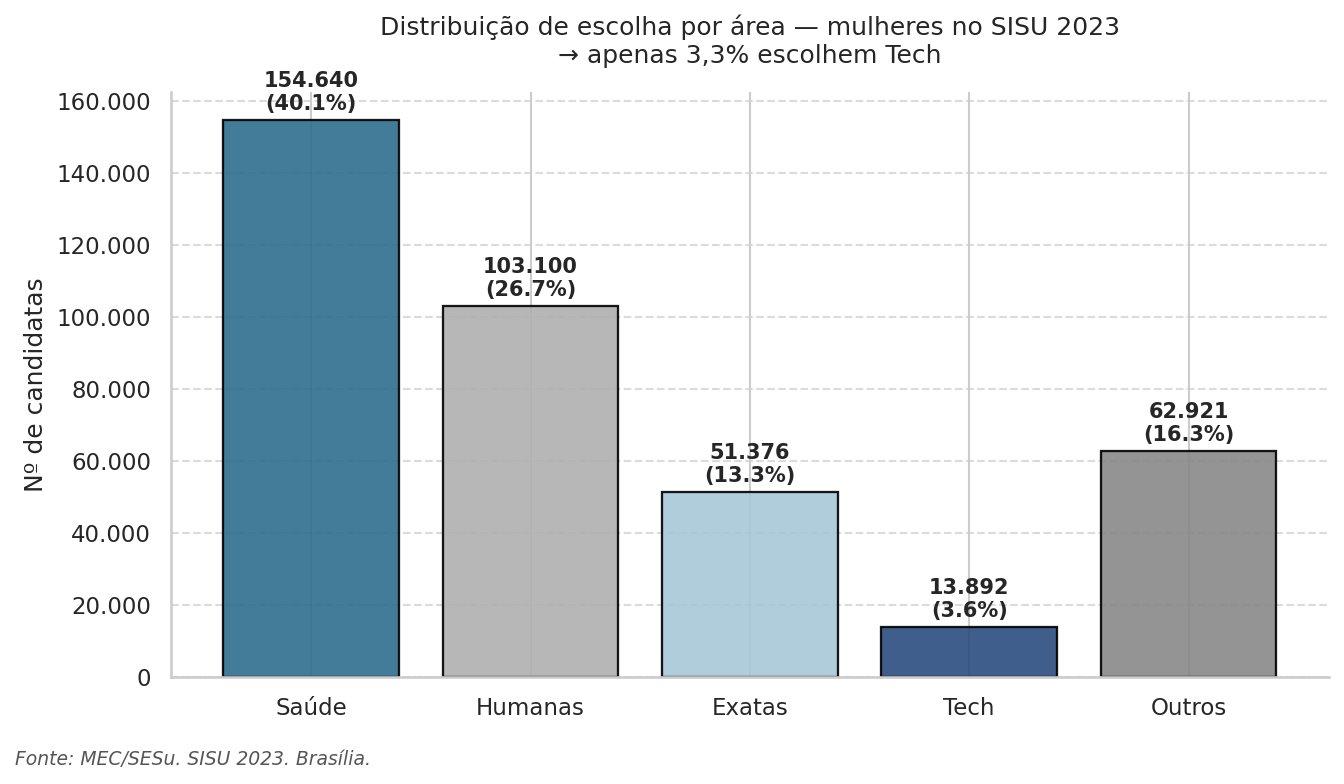

✅ Salvo: eda_sisu_area.png


In [ ]:
# BASE: df_sisu (2023)
def classificar_area(nome_curso):
    if pd.isna(nome_curso): return 'Outros'
    nome = unicodedata.normalize('NFD', str(nome_curso).upper().strip())
    nome = ''.join(c for c in nome if unicodedata.category(c) != 'Mn')
    if nome in {unicodedata.normalize('NFD', t).translate(
                str.maketrans('','','\u0300\u0301\u0302\u0303\u0304\u0308\u0327'))
                for t in CURSOS_TECH}: return 'Tech'
    for kw in ['MEDICINA','ENFERMAGEM','FARMACIA','ODONTOLOGIA','NUTRICAO',
               'FISIOTERAPIA','PSICOLOGIA','VETERINARIA','BIOMEDICINA',
               'FONOAUDIOLOGIA','TERAPIA OCUPACIONAL','EDUCACAO FISICA','SAUDE']:
        if kw in nome: return 'Saúde'
    for kw in ['ENGENHARIA','MATEMATICA','FISICA','QUIMICA',
               'ESTATISTICA','GEOLOGIA','ASTRONOMIA','ARQUITETURA']:
        if kw in nome: return 'Exatas'
    for kw in ['DIREITO','ADMINISTRACAO','ECONOMIA','CONTABILIDADE','PEDAGOGIA',
               'HISTORIA','GEOGRAFIA','FILOSOFIA','SOCIOLOGIA','LETRAS',
               'COMUNICACAO','JORNALISMO','PUBLICIDADE','RELACOES','GESTAO',
               'CIENCIAS SOCIAIS','SERVICO SOCIAL','TURISMO']:
        if kw in nome: return 'Humanas'
    return 'Outros'

df_sisu['AREA_CURSO'] = df_sisu['NOME_CURSO'].apply(classificar_area)

dist = df_sisu['AREA_CURSO'].value_counts()
print('=== Distribuição por área — mulheres SISU 2023 ===')
for area, n in dist.items():
    print(f'  {area:15s}: {n:>7,} ({n/len(df_sisu)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 5))
ordem_areas = ['Saúde','Humanas','Exatas','Tech','Outros']
vals   = [dist.get(a, 0) for a in ordem_areas]
cores_areas = [COR_FEM, COR_MASC, COR_BRANCA, COR_NEGRA, '#888888']
bars = ax.bar(ordem_areas, vals, color=cores_areas, edgecolor='black', linewidth=1.1, alpha=0.9)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + ax.get_ylim()[1]*0.01,
            f'{v:,}\n({v/len(df_sisu)*100:.1f}%)'.replace(',','.'),
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Nº de candidatas')
ax.set_title('Distribuição de escolha por área — mulheres no SISU 2023\n'
             '→ apenas 3,3% escolhem Tech', fontsize=12, pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
ax.grid(axis='y', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
fig.text(0.01, -0.03, FONTE_SISU, fontsize=9, color='#555555', style='italic')
save_fig('eda_sisu_area.png')


## Seção 4 — Modelo 1: fatores socioeconômicos → nota em Matemática

> **Base:** `df_enem` — 2021–2023

**Pergunta:** renda, raça, tipo de escola e escolaridade/ocupação dos pais predizem
a nota em MT entre mulheres?

Referência metodológica: Dantas et al. (2025) — replicado com recorte de gênero e raça.


### 4.1 — Preparar dataset

In [ ]:
# BASE: df_enem (2021–2023)
FEATURES_M1 = ['TP_COR_RACA','NEGRA','RENDA_NUM','ESCOL_MAX_PAIS',
               'ESCOLA_PUBLICA','REGIAO','OCUP_PAI','OCUP_MAE']
TARGET_M1   = 'NU_NOTA_MT'

df_model1 = df_enem[FEATURES_M1 + [TARGET_M1]].dropna()
print(f'Dataset Modelo 1 (2021–2023): {len(df_model1):,} linhas')
print(f'Anos: {sorted(df_enem.loc[df_model1.index, "NU_ANO"].unique())}')
print(f'Nota MT — média: {df_model1[TARGET_M1].mean():.1f} | dp: {df_model1[TARGET_M1].std():.1f}')


Dataset Modelo 1 (2021–2023): 985,906 linhas
Anos: [np.int64(2021), np.int64(2022), np.int64(2023)]
Nota MT — média: 540.1 | dp: 122.9


### 4.2 — Encoding e split

In [ ]:
df_enc1 = pd.get_dummies(df_model1, columns=['REGIAO'], drop_first=True)
X1 = df_enc1.drop(TARGET_M1, axis=1)
y1 = df_enc1[TARGET_M1]
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)
print(f'Treino: {len(X1_train):,} | Teste: {len(X1_test):,}')


Treino: 788,724 | Teste: 197,182


### 4.3 — Regressão Linear

In [ ]:
sc1 = StandardScaler()
X1_train_sc = sc1.fit_transform(X1_train)
X1_test_sc  = sc1.transform(X1_test)

lin1 = LinearRegression()
lin1.fit(X1_train_sc, y1_train)
y1_pred_lin = lin1.predict(X1_test_sc)

print('=== Regressão Linear — Modelo 1 ===')
print(f'R²:  {r2_score(y1_test, y1_pred_lin):.4f}')
print(f'MAE: {mean_absolute_error(y1_test, y1_pred_lin):.2f} pontos')

coef1 = pd.DataFrame({
    'variavel':    X1.columns,
    'coeficiente': lin1.coef_
}).sort_values('coeficiente', key=abs, ascending=False)
print('\nCoeficientes padronizados:')
print(coef1.head(15).to_string(index=False))


=== Regressão Linear — Modelo 1 ===
R²:  0.2567
MAE: 84.65 pontos

Coeficientes padronizados:
      variavel  coeficiente
      OCUP_PAI    21.549702
      OCUP_MAE    20.282917
         NEGRA   -16.256787
     RENDA_NUM    13.146303
ESCOL_MAX_PAIS    10.705892
     REGIAO_SE     8.074746
      REGIAO_N    -7.669937
ESCOLA_PUBLICA    -6.911467
     REGIAO_NE     1.902960
      REGIAO_S     1.304748
   TP_COR_RACA    -0.909552


### 4.4 — Random Forest

In [ ]:
rf1 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf1.fit(X1_train, y1_train)
y1_pred_rf = rf1.predict(X1_test)

print('=== Random Forest — Modelo 1 ===')
print(f'R²:  {r2_score(y1_test, y1_pred_rf):.4f}')
print(f'MAE: {mean_absolute_error(y1_test, y1_pred_rf):.2f} pontos')

feat1 = pd.DataFrame({
    'variavel':   X1.columns,
    'importancia': rf1.feature_importances_
}).sort_values('importancia', ascending=False)
print('\nImportância das variáveis (RF):')
print(feat1.head(12).to_string(index=False))


=== Random Forest — Modelo 1 ===
R²:  0.2902
MAE: 82.50 pontos

Importância das variáveis (RF):
      variavel  importancia
      OCUP_PAI     0.536050
ESCOL_MAX_PAIS     0.108897
      OCUP_MAE     0.108113
     RENDA_NUM     0.069931
   TP_COR_RACA     0.065997
         NEGRA     0.047718
     REGIAO_SE     0.033155
      REGIAO_N     0.021184
ESCOLA_PUBLICA     0.005950
      REGIAO_S     0.001925
     REGIAO_NE     0.001079


### 4.5 — Gráfico: coeficientes Modelo 1

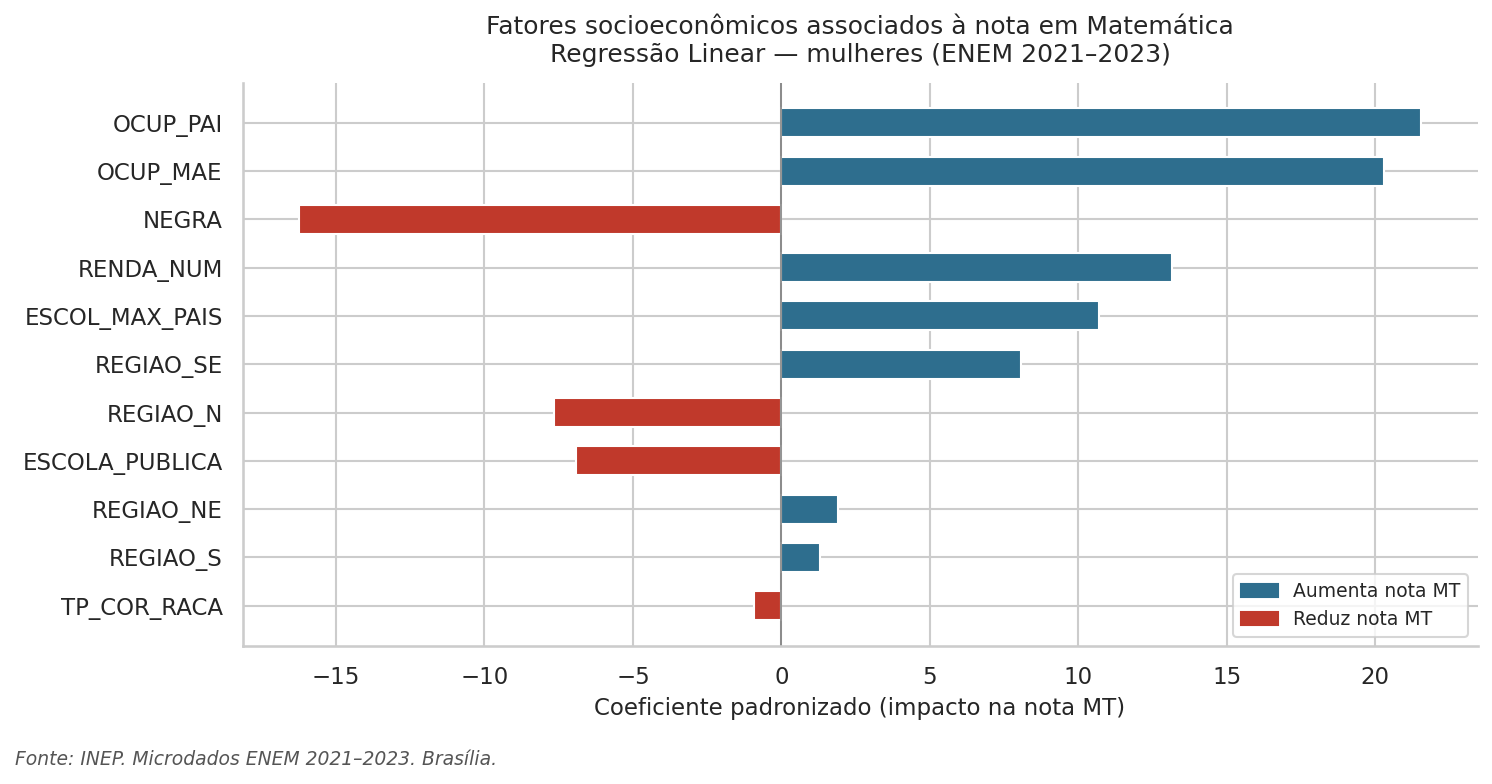

✅ Salvo: m1_coef_socio_nota.png


In [ ]:
top_c1    = coef1.head(12).copy()
cores_c1  = [COR_POS if c > 0 else COR_NEG for c in top_c1['coeficiente']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_c1['variavel'][::-1], top_c1['coeficiente'][::-1],
        color=cores_c1[::-1], edgecolor='white', height=0.6)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Coeficiente padronizado (impacto na nota MT)', fontsize=11)
ax.set_title('Fatores socioeconômicos associados à nota em Matemática\n'
             'Regressão Linear — mulheres (ENEM 2021–2023)', fontsize=12, pad=10)
ax.legend(handles=[
    Patch(color=COR_POS, label='Aumenta nota MT'),
    Patch(color=COR_NEG, label='Reduz nota MT')
], fontsize=9, loc='lower right')
fig.text(0.01, -0.03, FONTE_ENEM, fontsize=9, color='#555555', style='italic')
save_fig('m1_coef_socio_nota.png')


## Seção 5 — Modelo 2: notas → escolha tech

> **Base:** `df_sisu` — 2023, mulheres

**Pergunta:** notas e perfil socioeconômico predizem a escolha de curso tech entre mulheres?

**Desbalanceamento:** ~33:1. Solução: SMOTE no treino + avaliar por AUC-ROC e F1.


### 5.1 — Preparar dataset e balancear

In [ ]:
FEATURES_M2 = ['NOTA_M','NOTA_CN','NOTA_L','NOTA_CH','NOTA_R',
               'NOTA_CANDIDATO','IDADE','REGIAO','COTA','TURNO']

df_model2 = df_sisu[FEATURES_M2 + ['IS_TECH']].dropna()
print(f'Dataset Modelo 2: {len(df_model2):,}')
print(f'  Tech:     {df_model2["IS_TECH"].sum():,} ({df_model2["IS_TECH"].mean()*100:.1f}%)')
print(f'  Desbalanceamento: {(1-df_model2["IS_TECH"]).sum()/df_model2["IS_TECH"].sum():.0f}:1')

df_enc2 = pd.get_dummies(df_model2, columns=['REGIAO','COTA','TURNO'], drop_first=True)
X2 = df_enc2.drop('IS_TECH', axis=1)
y2 = df_enc2['IS_TECH']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

sm = SMOTE(random_state=42, k_neighbors=5)
X2_tr, y2_tr = sm.fit_resample(X2_train, y2_train)

print(f'\nTreino ANTES do SMOTE: {dict(zip(*np.unique(y2_train, return_counts=True)))}')
print(f'Treino APÓS o SMOTE:   {dict(zip(*np.unique(y2_tr, return_counts=True)))}')
print(f'Teste (original):      {dict(zip(*np.unique(y2_test, return_counts=True)))}')


Dataset Modelo 2: 385,929
  Tech:     13,789 (3.6%)
  Desbalanceamento: 27:1

Treino ANTES do SMOTE: {np.int64(0): np.int64(297712), np.int64(1): np.int64(11031)}
Treino APÓS o SMOTE:   {np.int64(0): np.int64(297712), np.int64(1): np.int64(297712)}
Teste (original):      {np.int64(0): np.int64(74428), np.int64(1): np.int64(2758)}


### 5.2 — Regressão Logística

In [ ]:
sc2 = StandardScaler()
X2_tr_sc = sc2.fit_transform(X2_tr)
X2_te_sc = sc2.transform(X2_test)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X2_tr_sc, y2_tr)
y2_pred_lr = lr2.predict(X2_te_sc)
y2_prob_lr = lr2.predict_proba(X2_te_sc)[:,1]

print('=== Regressão Logística — Modelo 2 ===')
print(classification_report(y2_test, y2_pred_lr, target_names=['Não-tech','Tech']))
print(f'AUC-ROC: {roc_auc_score(y2_test, y2_prob_lr):.4f}')

coef2 = pd.DataFrame({
    'variavel':    X2.columns,
    'coeficiente': lr2.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)
print('\nTop 10 fatores associados à escolha de tech:')
print(coef2.head(10).to_string(index=False))


=== Regressão Logística — Modelo 2 ===
              precision    recall  f1-score   support

    Não-tech       0.96      0.99      0.98     74428
        Tech       0.10      0.02      0.03      2758

    accuracy                           0.96     77186
   macro avg       0.53      0.51      0.50     77186
weighted avg       0.93      0.96      0.95     77186

AUC-ROC: 0.5808

Top 10 fatores associados à escolha de tech:
        variavel  coeficiente
   TURNO_Noturno     3.526905
  TURNO_Integral     3.122040
       REGIAO_NE     2.699463
       REGIAO_SE     2.580584
  TURNO_Matutino     2.125101
TURNO_Vespertino     1.827888
        REGIAO_S     1.810598
        REGIAO_N     1.684190
       COTA_Cota     0.465457
          NOTA_M     0.449722


### 5.3 — Árvore de Decisão e Random Forest

In [ ]:
dt2 = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                               class_weight='balanced', random_state=42)
dt2.fit(X2_tr, y2_tr)
y2_pred_dt = dt2.predict(X2_test)
y2_prob_dt = dt2.predict_proba(X2_test)[:,1]
print('=== Árvore de Decisão — Modelo 2 ===')
print(classification_report(y2_test, y2_pred_dt, target_names=['Não-tech','Tech']))
print(f'AUC-ROC: {roc_auc_score(y2_test, y2_prob_dt):.4f}')

rf2 = RandomForestClassifier(n_estimators=200, max_depth=10,
                               class_weight='balanced', random_state=42, n_jobs=-1)
rf2.fit(X2_tr, y2_tr)
y2_pred_rf = rf2.predict(X2_test)
y2_prob_rf = rf2.predict_proba(X2_test)[:,1]
print('\n=== Random Forest — Modelo 2 ===')
print(classification_report(y2_test, y2_pred_rf, target_names=['Não-tech','Tech']))
print(f'AUC-ROC: {roc_auc_score(y2_test, y2_prob_rf):.4f}')


=== Árvore de Decisão — Modelo 2 ===
              precision    recall  f1-score   support

    Não-tech       0.97      0.93      0.95     74428
        Tech       0.07      0.15      0.10      2758

    accuracy                           0.90     77186
   macro avg       0.52      0.54      0.52     77186
weighted avg       0.94      0.90      0.92     77186

AUC-ROC: 0.5892

=== Random Forest — Modelo 2 ===
              precision    recall  f1-score   support

    Não-tech       0.97      0.99      0.98     74428
        Tech       0.11      0.04      0.06      2758

    accuracy                           0.95     77186
   macro avg       0.54      0.51      0.52     77186
weighted avg       0.93      0.95      0.94     77186

AUC-ROC: 0.6216


## Seção 6 — Resultados gráficos

### 6.1 — Curvas ROC: Modelo 2

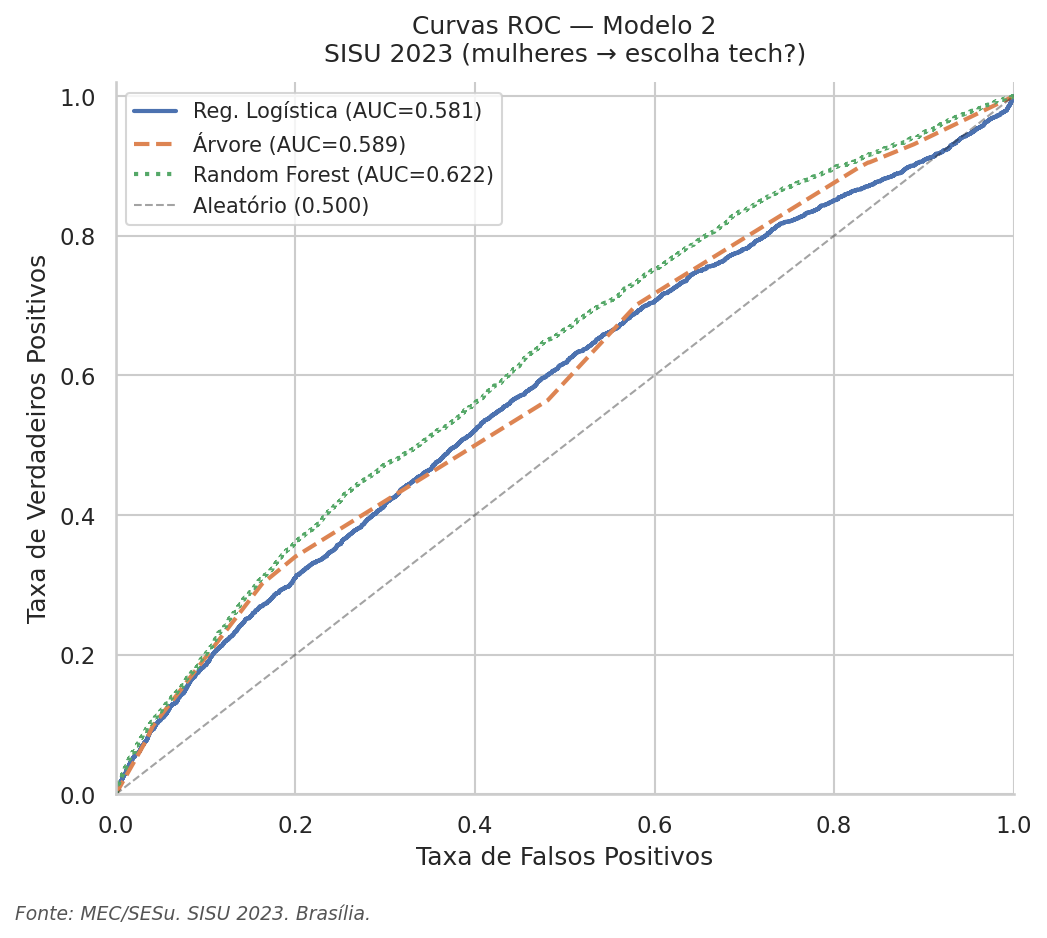

✅ Salvo: m2_roc_tech.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for nome, probs, ls in [('Reg. Logística', y2_prob_lr, 'solid'),
                        ('Árvore',         y2_prob_dt, 'dashed'),
                        ('Random Forest',  y2_prob_rf, 'dotted')]:
    fpr, tpr, _ = roc_curve(y2_test, probs)
    ax.plot(fpr, tpr, lw=2, linestyle=ls,
            label=f'{nome} (AUC={roc_auc_score(y2_test, probs):.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Aleatório (0.500)')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curvas ROC — Modelo 2\nSISU 2023 (mulheres → escolha tech?)',
             fontsize=12, pad=10)
ax.legend(fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
fig.text(0.01, -0.03, FONTE_SISU, fontsize=9, color='#555555', style='italic')
save_fig('m2_roc_tech.png')


### 6.2 — Achado central: nota MT não diferencia quem entra em tech

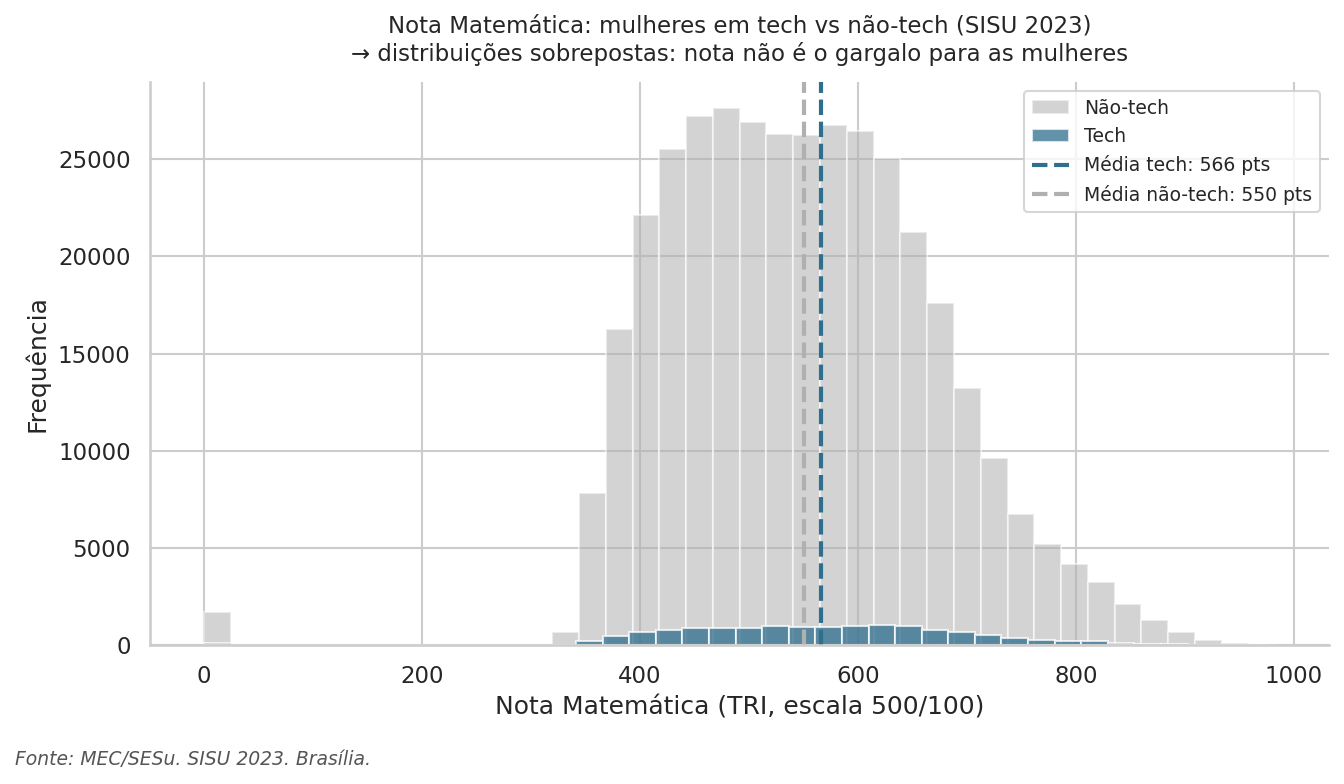

✅ Salvo: achado_nota_nao_gargalo.png
Correlação NOTA_M × IS_TECH — Mulheres: 0.0240
Mulheres em tech    — nota MT média: 565.8
Mulheres fora de tech — nota MT média: 550.2
Diferença: 15.6 pts


In [ ]:
f_tech    = df_sisu[df_sisu['IS_TECH']==1]['NOTA_M'].dropna()
f_nontech = df_sisu[df_sisu['IS_TECH']==0]['NOTA_M'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(f_nontech, bins=40, alpha=0.55, color=COR_MASC, label='Não-tech')
ax.hist(f_tech,    bins=40, alpha=0.75, color=COR_FEM,  label='Tech')
ax.axvline(f_tech.mean(),    color=COR_FEM,  linestyle='--', lw=2,
           label=f'Média tech: {f_tech.mean():.0f} pts')
ax.axvline(f_nontech.mean(), color=COR_MASC, linestyle='--', lw=2,
           label=f'Média não-tech: {f_nontech.mean():.0f} pts')
ax.set_title('Nota Matemática: mulheres em tech vs não-tech (SISU 2023)\n'
             '→ distribuições sobrepostas: nota não é o gargalo para as mulheres',
             fontsize=11, pad=10)
ax.set_xlabel('Nota Matemática (TRI, escala 500/100)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=9)
fig.text(0.01, -0.03, FONTE_SISU, fontsize=9, color='#555555', style='italic')
save_fig('achado_nota_nao_gargalo.png')

corr_f = df_sisu['NOTA_M'].corr(df_sisu['IS_TECH'])
print(f'Correlação NOTA_M × IS_TECH — Mulheres: {corr_f:.4f}')
print(f'Mulheres em tech    — nota MT média: {f_tech.mean():.1f}')
print(f'Mulheres fora de tech — nota MT média: {f_nontech.mean():.1f}')
print(f'Diferença: {f_tech.mean()-f_nontech.mean():.1f} pts')


### 6.3 — Tabela-resumo dos modelos

In [ ]:
resumo = pd.DataFrame([
    {'Modelo':'M1 — Regressão Linear','Base':'ENEM 2021–2023',
     'Pergunta':'Socioec. → nota MT (mulheres)',
     'Métrica':f'R²={r2_score(y1_test, y1_pred_lin):.3f}',
     'MAE':f'{mean_absolute_error(y1_test, y1_pred_lin):.1f} pts',
     'Interpretável':'Sim — coef. padronizados'},
    {'Modelo':'M1 — Random Forest','Base':'ENEM 2021–2023',
     'Pergunta':'Socioec. → nota MT (mulheres)',
     'Métrica':f'R²={r2_score(y1_test, y1_pred_rf):.3f}',
     'MAE':f'{mean_absolute_error(y1_test, y1_pred_rf):.1f} pts',
     'Interpretável':'Parcial — feat. importance'},
    {'Modelo':'M2 — Regressão Logística','Base':'SISU 2023',
     'Pergunta':'Notas → escolha tech (mulheres)',
     'Métrica':f'AUC={roc_auc_score(y2_test, y2_prob_lr):.3f}',
     'MAE':f'F1={f1_score(y2_test, y2_pred_lr):.3f}',
     'Interpretável':'Sim — log-odds'},
    {'Modelo':'M2 — Árvore de Decisão','Base':'SISU 2023',
     'Pergunta':'Notas → escolha tech (mulheres)',
     'Métrica':f'AUC={roc_auc_score(y2_test, y2_prob_dt):.3f}',
     'MAE':f'F1={f1_score(y2_test, y2_pred_dt):.3f}',
     'Interpretável':'Sim — regras'},
    {'Modelo':'M2 — Random Forest','Base':'SISU 2023',
     'Pergunta':'Notas → escolha tech (mulheres)',
     'Métrica':f'AUC={roc_auc_score(y2_test, y2_prob_rf):.3f}',
     'MAE':f'F1={f1_score(y2_test, y2_pred_rf):.3f}',
     'Interpretável':'Parcial'},
])
print('=' * 90)
print('RESUMO DOS MODELOS — Mulheres na liderança em tecnologia')
print('=' * 90)
display(resumo)


RESUMO DOS MODELOS — Mulheres na liderança em tecnologia


,Modelo,Base,Pergunta,Métrica,MAE,Interpretável
0,M1 — Regressão Linear,ENEM 2021–2023,Socioec. → nota MT (mulheres),R²=0.257,84.6 pts,Sim — coef. padronizados
1,M1 — Random Forest,ENEM 2021–2023,Socioec. → nota MT (mulheres),R²=0.290,82.5 pts,Parcial — feat. importance
2,M2 — Regressão Logística,SISU 2023,Notas → escolha tech (mulheres),AUC=0.581,F1=0.026,Sim — log-odds
3,M2 — Árvore de Decisão,SISU 2023,Notas → escolha tech (mulheres),AUC=0.589,F1=0.097,Sim — regras
4,M2 — Random Forest,SISU 2023,Notas → escolha tech (mulheres),AUC=0.622,F1=0.058,Parcial


## Seção 7 — Análises adicionais

| Item | Pergunta | Base |
|------|----------|------|
| 7.1 | Nota de corte vs candidata — folga de nota | SISU 2023 |
| 7.2 | Gap racial por área de conhecimento | ENEM 2021–2023 |
| 7.3 | Modelo 2 para homens — comparar AUC | SISU 2023 |
| 7.4 | Evolução temporal do gap racial 2018–2023 | **ENEM 2018–2023** |


### 7.1 — Folga de nota: candidata vs corte do curso

=== Folga de nota: mulheres tech vs não-tech ===
           mean  median    std   count
IS_TECH                               
Não-tech -88.91  -83.01  82.37  370368
Tech     -90.96  -85.43  83.58   13764


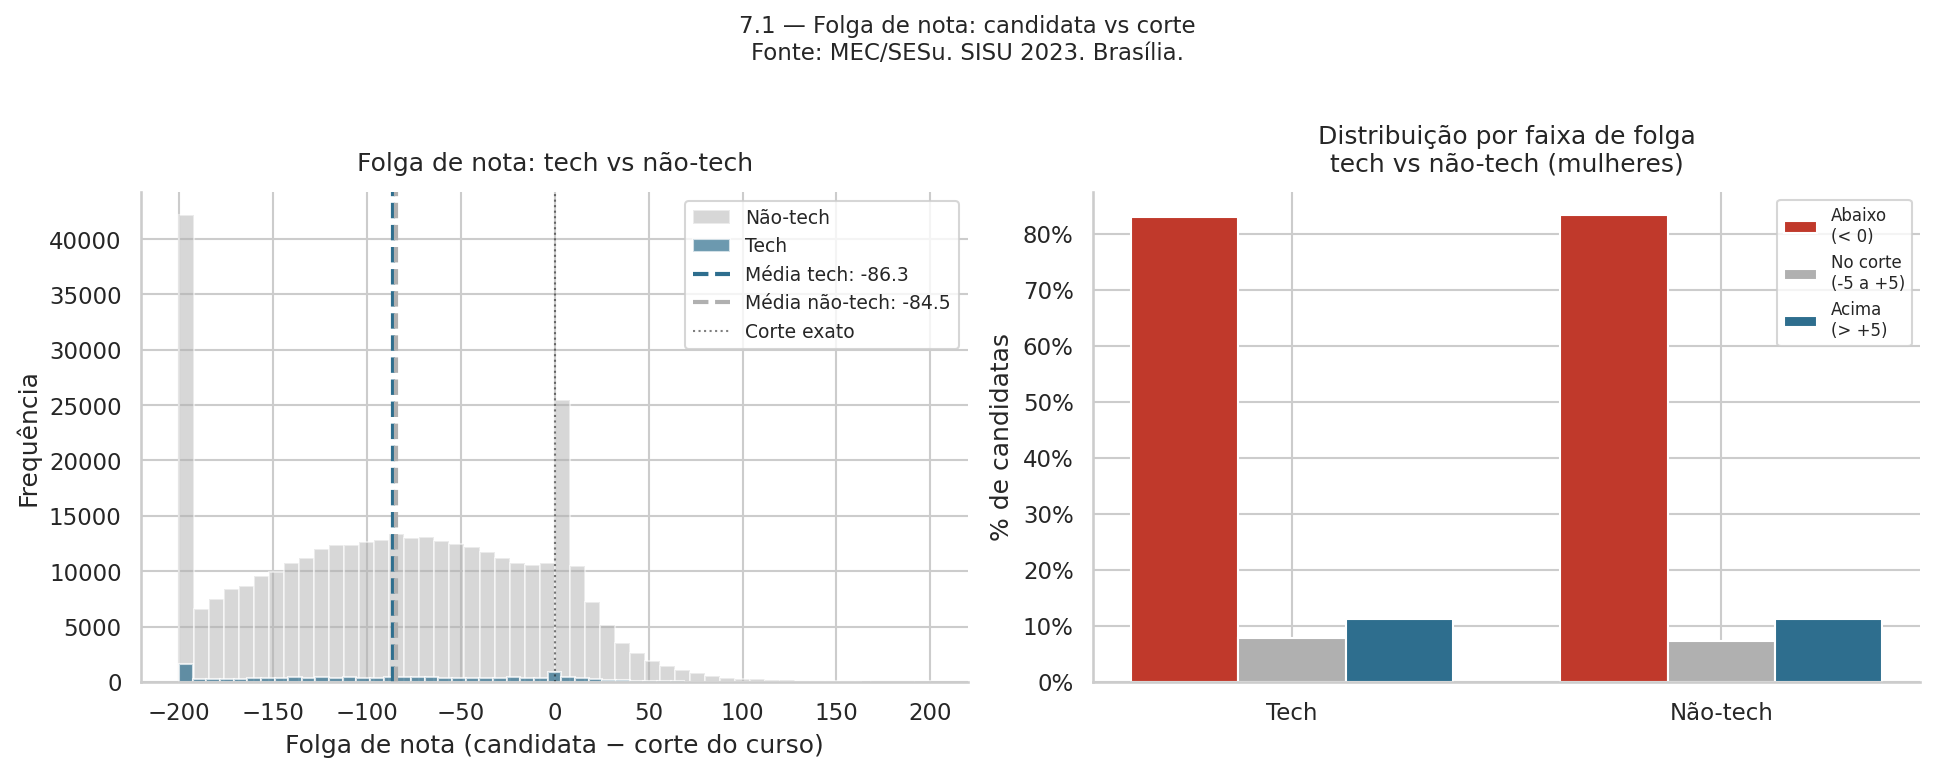

✅ Salvo: 71_folga_nota.png


In [ ]:
# BASE: df_sisu (2023)
for col in ['NOTA_CANDIDATO','NOTA_CORTE']:
    if col in df_sisu.columns:
        df_sisu[col] = pd.to_numeric(
            df_sisu[col].astype(str).str.replace(',','.', regex=False), errors='coerce')

df_sisu['FOLGA_NOTA'] = df_sisu['NOTA_CANDIDATO'] - df_sisu['NOTA_CORTE']
df_folga = df_sisu[df_sisu['FOLGA_NOTA'].notna()].copy()

print('=== Folga de nota: mulheres tech vs não-tech ===')
print(df_folga.groupby('IS_TECH')['FOLGA_NOTA']
      .agg(['mean','median','std','count'])
      .rename(index={0:'Não-tech',1:'Tech'}).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ft = df_folga[df_folga['IS_TECH']==1]['FOLGA_NOTA'].clip(-200,200)
fn = df_folga[df_folga['IS_TECH']==0]['FOLGA_NOTA'].clip(-200,200)
ax.hist(fn, bins=50, alpha=0.5, color=COR_MASC, label='Não-tech')
ax.hist(ft, bins=50, alpha=0.7, color=COR_FEM,  label='Tech')
ax.axvline(ft.mean(), color=COR_FEM,  linestyle='--', lw=2,
           label=f'Média tech: {ft.mean():.1f}')
ax.axvline(fn.mean(), color=COR_MASC, linestyle='--', lw=2,
           label=f'Média não-tech: {fn.mean():.1f}')
ax.axvline(0, color='black', linestyle=':', lw=1, alpha=0.5, label='Corte exato')
ax.set_xlabel('Folga de nota (candidata − corte do curso)')
ax.set_ylabel('Frequência')
ax.set_title('Folga de nota: tech vs não-tech', fontsize=12, pad=10)
ax.legend(fontsize=9)

ax2 = axes[1]
grupos_folga = {'Tech': ft, 'Não-tech': fn}
faixas = [('Abaixo\n(< 0)', lambda s: s < 0),
          ('No corte\n(-5 a +5)', lambda s: (s>=-5)&(s<=5)),
          ('Acima\n(> +5)', lambda s: s > 5)]
x_pos = np.arange(len(grupos_folga))
w2    = 0.25
cores_faixas = [COR_NEG, COR_MASC, COR_FEM]
for j, (lbl, fn_faixa, cor) in enumerate(zip(
        [f[0] for f in faixas], [f[1] for f in faixas], cores_faixas)):
    vals = [fn_faixa(s).mean()*100 for s in grupos_folga.values()]
    ax2.bar(x_pos + j*w2, vals, width=w2, color=cor, label=lbl, edgecolor='white')
ax2.set_xticks(x_pos + w2); ax2.set_xticklabels(grupos_folga.keys())
ax2.set_ylabel('% de candidatas')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_title('Distribuição por faixa de folga\ntech vs não-tech (mulheres)',
              fontsize=12, pad=10)
ax2.legend(fontsize=8, loc='upper right')

plt.suptitle('7.1 — Folga de nota: candidata vs corte\n' + FONTE_SISU,
             fontsize=11, y=1.02)
save_fig('71_folga_nota.png')


### 7.2 — Gap racial por área de conhecimento

=== Média de nota por área e grupo racial (mulheres, 2021–2023) ===
Área                               Branca      Negra    Gap (B-N)
-----------------------------------------------------------------
  Matemática (MT)                   576.0      506.1        +69.9
  Ciências Natureza (CN)            524.3      478.4        +45.8
  Linguagens (LC)                   548.3      505.3        +43.0
  Ciências Humanas (CH)             559.5      511.9        +47.6
  Redação                           724.0      642.9        +81.1


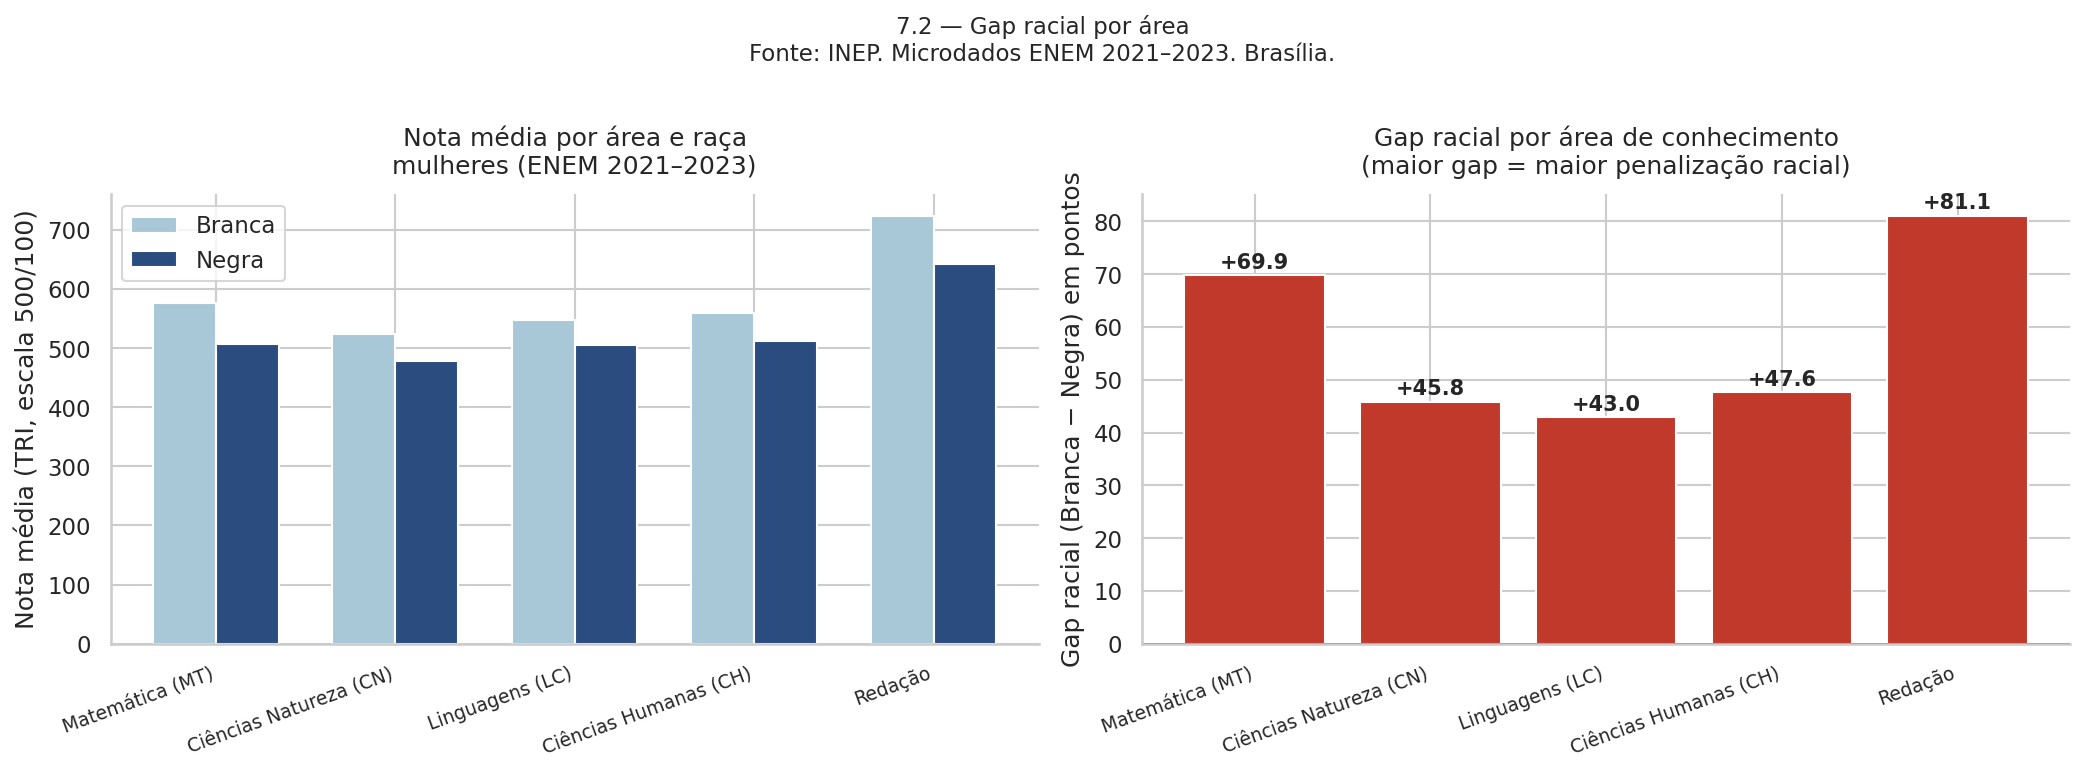

✅ Salvo: 72_gap_racial_areas.png


In [ ]:
# BASE: df_enem (2021–2023)
areas = {
    'Matemática (MT)':        'NU_NOTA_MT',
    'Ciências Natureza (CN)': 'NU_NOTA_CN',
    'Linguagens (LC)':        'NU_NOTA_LC',
    'Ciências Humanas (CH)':  'NU_NOTA_CH',
    'Redação':                'NU_NOTA_REDACAO',
}
df_gap = df_enem[df_enem['GRUPO_RACA'].isin(['Branca','Negra'])].copy()

print('=== Média de nota por área e grupo racial (mulheres, 2021–2023) ===')
print(f'{"Área":30s} {"Branca":>10s} {"Negra":>10s} {"Gap (B-N)":>12s}')
print('-' * 65)

gaps = {}
for nome_area, col in areas.items():
    if col not in df_gap.columns: continue
    mb = df_gap[df_gap['GRUPO_RACA']=='Branca'][col].mean()
    mn = df_gap[df_gap['GRUPO_RACA']=='Negra'][col].mean()
    gaps[nome_area] = {'Branca':mb,'Negra':mn,'Gap':mb-mn}
    print(f'  {nome_area:28s} {mb:>10.1f} {mn:>10.1f} {mb-mn:>+12.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
nomes  = list(gaps.keys())
branca = [gaps[n]['Branca'] for n in nomes]
negra  = [gaps[n]['Negra']  for n in nomes]
x = np.arange(len(nomes)); w = 0.35
ax.bar(x-w/2, branca, width=w, color=COR_BRANCA, label='Branca', edgecolor='white')
ax.bar(x+w/2, negra,  width=w, color=COR_NEGRA,  label='Negra',  edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Nota média (TRI, escala 500/100)')
ax.set_title('Nota média por área e raça\nmulheres (ENEM 2021–2023)', fontsize=12, pad=10)
ax.legend()

ax2 = axes[1]
gap_vals    = [gaps[n]['Gap'] for n in nomes]
cores_gap   = [COR_NEG if g > 40 else COR_MASC for g in gap_vals]
bars = ax2.bar(nomes, gap_vals, color=cores_gap, edgecolor='white')
ax2.set_xticklabels(nomes, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Gap racial (Branca − Negra) em pontos')
ax2.set_title('Gap racial por área de conhecimento\n'
              '(maior gap = maior penalização racial)', fontsize=12, pad=10)
ax2.axhline(0, color='black', lw=0.8)
for bar, val in zip(bars, gap_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.5,
             f'+{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('7.2 — Gap racial por área\n' + FONTE_ENEM, fontsize=11, y=1.02)
save_fig('72_gap_racial_areas.png')


### 7.3 — Modelo 2 para homens: comparar AUC

In [ ]:
# BASE: arquivos originais SISU 2023 (homens)
arquivos = [
    PASTA + 'chamada_regular_sisu_2023_1.csv',
    PASTA + 'chamada_regular_sisu_2023_2.csv',
    PASTA + 'lista_de_espera_sisu_2023_1.csv',
    PASTA + 'lista_de_espera_sisu_2023_2.csv',
]
COLS_SISU_M = ['SEXO','NOME_CURSO','TURNO','MOD_CONCORRENCIA','TP_COTA',
               'UF_CANDIDATO','DT_NASCIMENTO','OPCAO',
               'NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R','NOTA_CANDIDATO']

dfs_m = []
for path in arquivos:
    if not os.path.exists(path):
        print(f'Não encontrado: {path}'); continue
    df_arq = pd.read_csv(path, sep='|', encoding='latin1',
                          low_memory=False, usecols=COLS_SISU_M)
    homens = df_arq[(df_arq['SEXO']=='M') & (df_arq['OPCAO']==1)]
    print(f'{os.path.basename(path)}: {len(homens):,} homens')
    dfs_m.append(homens)

df_sisu_m = pd.concat(dfs_m, ignore_index=True)
print(f'\nTotal homens: {len(df_sisu_m):,}')


chamada_regular_sisu_2023_1.csv: 407,178 homens
chamada_regular_sisu_2023_2.csv: 102,585 homens
lista_de_espera_sisu_2023_1.csv: 147,839 homens
lista_de_espera_sisu_2023_2.csv: 33,673 homens

Total homens: 691,275


In [ ]:
for col in ['NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R','NOTA_CANDIDATO']:
    df_sisu_m[col] = pd.to_numeric(
        df_sisu_m[col].astype(str).str.replace(',','.', regex=False), errors='coerce')

df_sisu_m['IDADE']  = (2023 - pd.to_numeric(df_sisu_m['DT_NASCIMENTO'], errors='coerce')).clip(15,75)
df_sisu_m['REGIAO'] = df_sisu_m['UF_CANDIDATO'].map(REGIOES).fillna('N/D')
df_sisu_m['COTA']   = df_sisu_m['MOD_CONCORRENCIA'].apply(
    lambda x: 'Ampla' if str(x).lower() == 'ampla concorrência' else 'Cota')
df_sisu_m['IS_TECH'] = df_sisu_m['NOME_CURSO'].isin(CURSOS_TECH).astype(int)

FEATURES_M2 = ['NOTA_M','NOTA_CN','NOTA_L','NOTA_CH','NOTA_R',
               'NOTA_CANDIDATO','IDADE','REGIAO','COTA','TURNO']

df_model2_m = df_sisu_m[FEATURES_M2 + ['IS_TECH']].dropna()
df_enc_m    = pd.get_dummies(df_model2_m, columns=['REGIAO','COTA','TURNO'], drop_first=True)
X_m = df_enc_m.drop('IS_TECH', axis=1).reindex(columns=X2.columns, fill_value=0)
y_m = df_enc_m['IS_TECH']

Xm_tr_raw, Xm_test, ym_tr_raw, ym_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, stratify=y_m)
sm_m = SMOTE(random_state=42, k_neighbors=5)
Xm_tr, ym_tr = sm_m.fit_resample(Xm_tr_raw, ym_tr_raw)

sc_m = StandardScaler()
lr_m = LogisticRegression(max_iter=1000, random_state=42)
lr_m.fit(sc_m.fit_transform(Xm_tr), ym_tr)
ym_prob_lr = lr_m.predict_proba(sc_m.transform(Xm_test))[:,1]

rf_m = RandomForestClassifier(n_estimators=200, max_depth=10,
                               class_weight='balanced', random_state=42, n_jobs=-1)
rf_m.fit(Xm_tr, ym_tr)
ym_prob_rf = rf_m.predict_proba(Xm_test)[:,1]

print('=== COMPARAÇÃO AUC: mulheres vs homens ===')
print(f'{"":20s} {"Mulheres":>10s} {"Homens":>10s} {"Diferença":>12s}')
for nome, auc_f, auc_m in [
    ('Logística',    roc_auc_score(y2_test, y2_prob_lr), roc_auc_score(ym_test, ym_prob_lr)),
    ('Random Forest',roc_auc_score(y2_test, y2_prob_rf), roc_auc_score(ym_test, ym_prob_rf)),
]:
    print(f'  {nome:18s} {auc_f:>10.3f} {auc_m:>10.3f} {auc_m-auc_f:>+12.3f}')

corr_f = df_sisu['NOTA_M'].corr(df_sisu['IS_TECH'])
corr_m = df_sisu_m['NOTA_M'].corr(df_sisu_m['IS_TECH'])
print(f'\nCorrelação NOTA_M × IS_TECH:')
print(f'  Mulheres: r = {corr_f:.4f}')
print(f'  Homens:   r = {corr_m:.4f}')
print(f'  Diferença: {corr_m-corr_f:+.4f}')


=== COMPARAÇÃO AUC: mulheres vs homens ===
                       Mulheres     Homens    Diferença
  Logística               0.581      0.603       +0.022
  Random Forest           0.622      0.657       +0.035

Correlação NOTA_M × IS_TECH:
  Mulheres: r = 0.0240
  Homens:   r = 0.0539
  Diferença: +0.0298


### 7.4 — Evolução temporal do gap racial (2018–2023)

> ⚠️ **Base:** `df_enem_full` — **2018–2023** — única seção que usa dados anteriores a 2021.


Anos disponíveis para série temporal: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

=== Gap racial por ano (Branca − Negra, mulheres) ===
Área                          2018     2019     2020     2021     2022     2023   Variação
-----------------------------------------------------------------------------------------------
  Matemática (MT)             45.8     56.4     71.8     63.5     68.3     77.2 +31.4 PIORA
  Ciências Natureza (CN)      37.3     41.5     48.2     47.1     41.3     48.9 +11.7 PIORA
  Redação                     69.1     70.0     84.6     71.2     85.5     86.4 +17.2 PIORA


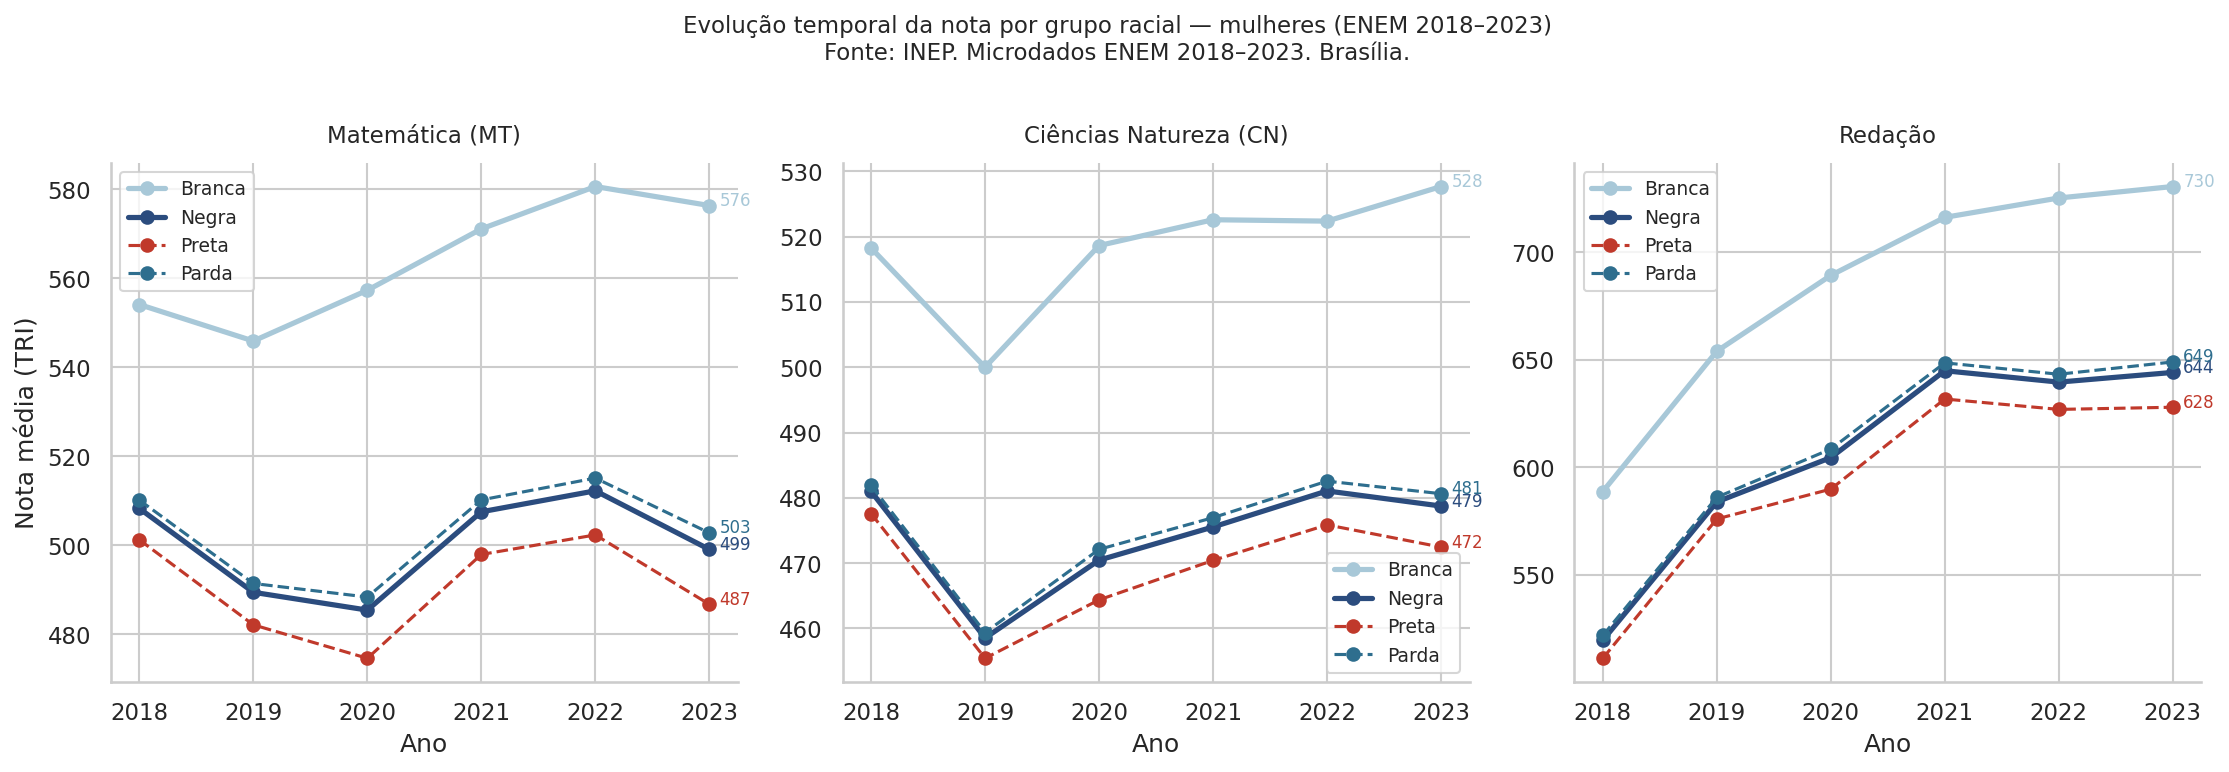

✅ Salvo: 74_evolucao_notas.png


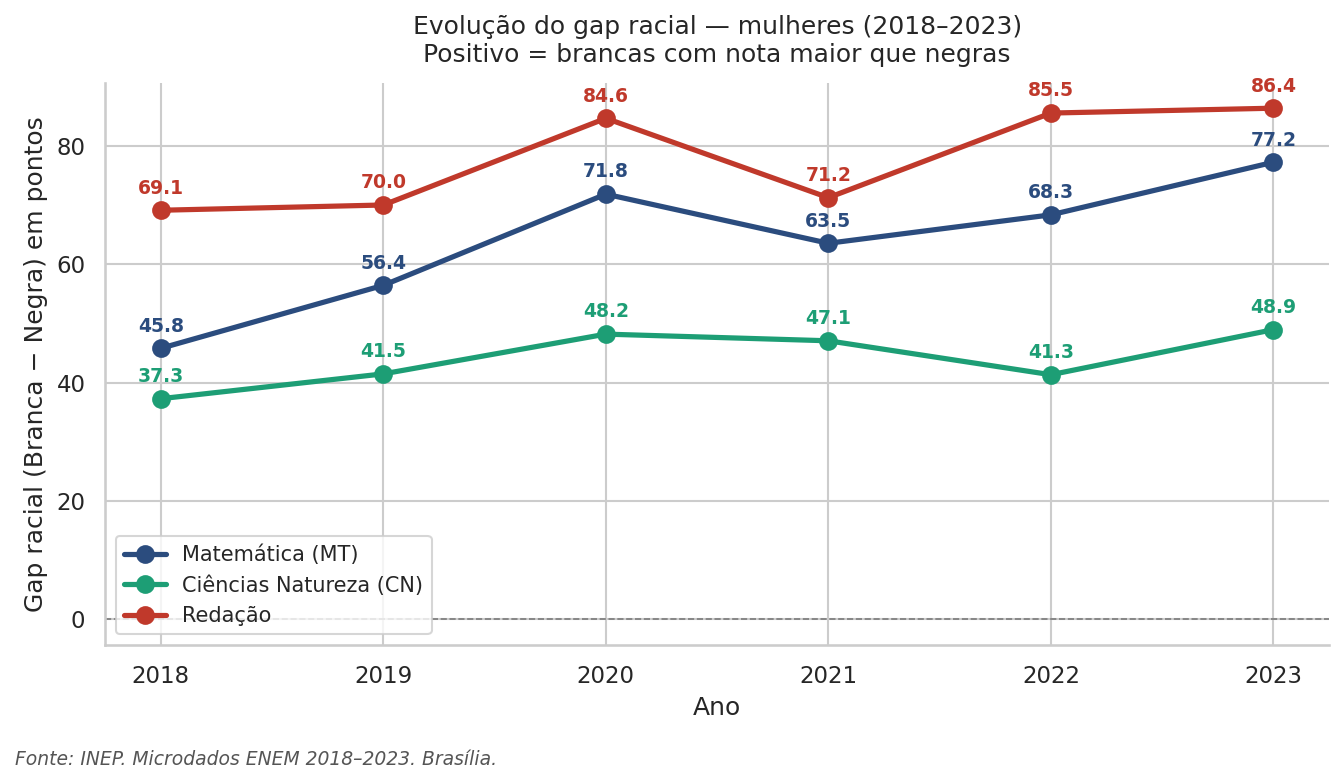

✅ Salvo: 74_gap_tendencia.png

=== Volume por ano e grupo (mulheres) ===
GRUPO_RACA  Branca   Negra
NU_ANO                    
2018        254240  447873
2019        232590  433401
2020        171004  281890
2021        160333  207003
2022        155900  203475
2023        167080  223477


In [ ]:
# BASE: df_enem_full (2018–2023) — ÚNICA célula que usa essa base
assert 'df_enem_full' in dir(), 'Rode a célula 2.1 antes desta'
anos = sorted(df_enem_full['NU_ANO'].unique())
print(f'Anos disponíveis para série temporal: {anos}')

areas_temp = {
    'Matemática (MT)':        'NU_NOTA_MT',
    'Ciências Natureza (CN)': 'NU_NOTA_CN',
    'Redação':                'NU_NOTA_REDACAO',
}

registros = []
for ano in anos:
    df_ano = df_enem_full[df_enem_full['NU_ANO'] == ano]
    for grupo in ['Branca','Negra','Preta','Parda']:
        df_g = (df_ano[df_ano['GRUPO_RACA'] == grupo] if grupo in ['Branca','Negra']
                else df_ano[df_ano['RACA_LABEL'] == grupo])
        for nome_area, col in areas_temp.items():
            if col in df_g.columns:
                registros.append({'ANO':ano,'GRUPO':grupo,'AREA':nome_area,
                                  'MEDIA':df_g[col].mean()})

df_temp = pd.DataFrame(registros)
df_piv  = (df_temp[df_temp['GRUPO'].isin(['Branca','Negra'])]
           .pivot_table(index=['ANO','AREA'], columns='GRUPO', values='MEDIA')
           .reset_index())
df_piv['GAP'] = df_piv['Branca'] - df_piv['Negra']

print('\n=== Gap racial por ano (Branca − Negra, mulheres) ===')
print(f'{"Área":25s} ' + ' '.join([f'{a:>8d}' for a in anos]) + f' {"Variação":>10s}')
print('-' * 95)
for area in areas_temp:
    row  = df_piv[df_piv['AREA'] == area].sort_values('ANO')
    gaps = row['GAP'].values
    if len(gaps) >= 2:
        var   = gaps[-1] - gaps[0]
        sinal = f'{var:+.1f} PIORA' if var > 1 else f'{var:+.1f} MELHORA' if var < -1 else 'ESTÁVEL'
        linha = f'  {area:23s} ' + ' '.join([f'{g:>8.1f}' for g in gaps])
        print(f'{linha} {sinal:>10s}')

# Gráfico 1: evolução das médias
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cores_g = {'Branca':COR_BRANCA,'Negra':COR_NEGRA,'Preta':COR_NEG,'Parda':COR_FEM}

for idx_a, (nome_area, col) in enumerate(areas_temp.items()):
    ax = axes[idx_a]
    for grupo in ['Branca','Negra','Preta','Parda']:
        dados_g = df_temp[(df_temp['GRUPO']==grupo) &
                          (df_temp['AREA']==nome_area)].sort_values('ANO')
        if len(dados_g) == 0: continue
        ls = 'solid' if grupo in ['Branca','Negra'] else 'dashed'
        lw = 2.5 if grupo in ['Branca','Negra'] else 1.5
        ax.plot(dados_g['ANO'], dados_g['MEDIA'], color=cores_g[grupo],
                lw=lw, linestyle=ls, marker='o', markersize=6, label=grupo)
        ultimo = dados_g.iloc[-1]
        ax.annotate(f'{ultimo["MEDIA"]:.0f}', (ultimo['ANO'], ultimo['MEDIA']),
                    textcoords='offset points', xytext=(5,0),
                    fontsize=8, color=cores_g[grupo])
    ax.set_title(nome_area, fontsize=11, pad=10)
    ax.set_xlabel('Ano')
    if idx_a == 0: ax.set_ylabel('Nota média (TRI)')
    ax.set_xticks(anos); ax.legend(fontsize=9)

plt.suptitle('Evolução temporal da nota por grupo racial — mulheres (ENEM 2018–2023)\n'
             'Fonte: INEP. Microdados ENEM 2018–2023. Brasília.',
             fontsize=11, y=1.02)
save_fig('74_evolucao_notas.png')

# Gráfico 2: evolução do gap
fig2, ax2 = plt.subplots(figsize=(9, 5))
cores_areas_t = {'Matemática (MT)':COR_NEGRA,
                 'Ciências Natureza (CN)':'#1D9E75',
                 'Redação':COR_NEG}
for area, cor in cores_areas_t.items():
    row = df_piv[df_piv['AREA']==area].sort_values('ANO')
    if len(row) == 0: continue
    ax2.plot(row['ANO'], row['GAP'], color=cor, lw=2.5,
             marker='o', markersize=8, label=area)
    for _, r in row.iterrows():
        ax2.annotate(f'{r["GAP"]:.1f}', (r['ANO'], r['GAP']),
                     textcoords='offset points', xytext=(0,8),
                     ha='center', fontsize=9, color=cor, fontweight='bold')
ax2.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax2.set_xlabel('Ano'); ax2.set_ylabel('Gap racial (Branca − Negra) em pontos')
ax2.set_title('Evolução do gap racial — mulheres (2018–2023)\n'
              'Positivo = brancas com nota maior que negras', fontsize=12, pad=10)
ax2.set_xticks(anos); ax2.legend(fontsize=10)
fig2.text(0.01, -0.03, 'Fonte: INEP. Microdados ENEM 2018–2023. Brasília.',
          fontsize=9, color='#555555', style='italic')
save_fig('74_gap_tendencia.png')

print('\n=== Volume por ano e grupo (mulheres) ===')
print(df_enem_full.groupby(['NU_ANO','GRUPO_RACA']).size()
      .unstack(fill_value=0)[['Branca','Negra']].to_string())


## Seção 8 — Modelos expandidos

| Modelo | Pergunta | Base |
|--------|----------|------|
| 8.1 — Multiclasse | Qual área a mulher vai escolher? | SISU 2023 |
| 8.2 — Por subgrupo racial | Retorno socioeconômico igual para todas? | ENEM 2021–2023 |


### 8.1 — Classificação multiclasse: qual área a mulher vai escolher?

In [ ]:
# BASE: df_sisu (2023) — AREA_CURSO já criada na célula 3.4
print('=== Distribuição por área (mulheres, SISU 2023) ===')
dist = df_sisu['AREA_CURSO'].value_counts()
for area, n in dist.items():
    print(f'  {area:15s}: {n:>7,} ({n/len(df_sisu)*100:.1f}%)')

FEATURES_MC = ['NOTA_M','NOTA_CN','NOTA_L','NOTA_CH','NOTA_R',
               'NOTA_CANDIDATO','IDADE','REGIAO','COTA','TURNO']
df_mc = df_sisu[FEATURES_MC + ['AREA_CURSO']].dropna()
df_mc = df_mc[df_mc['AREA_CURSO'] != 'Outros']
print(f'\nDataset multiclasse: {len(df_mc):,} linhas')

df_enc_mc = pd.get_dummies(df_mc, columns=['REGIAO','COTA','TURNO'], drop_first=True)
X_mc = df_enc_mc.drop('AREA_CURSO', axis=1)
y_mc = df_enc_mc['AREA_CURSO']

X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

rf_mc = RandomForestClassifier(n_estimators=200, max_depth=10,
                                class_weight='balanced', random_state=42, n_jobs=-1)
rf_mc.fit(X_mc_train, y_mc_train)
y_mc_pred = rf_mc.predict(X_mc_test)

print('\n=== RF Multiclasse — SISU 2023 ===')
print(classification_report(y_mc_test, y_mc_pred, zero_division=0))


=== Distribuição por área (mulheres, SISU 2023) ===
  Saúde          : 154,640 (40.1%)
  Humanas        : 103,100 (26.7%)
  Outros         :  62,921 (16.3%)
  Exatas         :  51,376 (13.3%)
  Tech           :  13,892 (3.6%)

Dataset multiclasse: 323,008 linhas

=== RF Multiclasse — SISU 2023 ===
              precision    recall  f1-score   support

      Exatas       0.28      0.20      0.23     10275
     Humanas       0.70      0.74      0.72     20620
       Saúde       0.73      0.77      0.75     30928
        Tech       0.13      0.14      0.14      2779

    accuracy                           0.64     64602
   macro avg       0.46      0.46      0.46     64602
weighted avg       0.62      0.64      0.63     64602



=== F1 por área ===
  Saúde          : F1=0.748
  Humanas        : F1=0.718
  Exatas         : F1=0.232
  Tech           : F1=0.136

  F1-macro:    0.458
  F1-weighted: 0.630


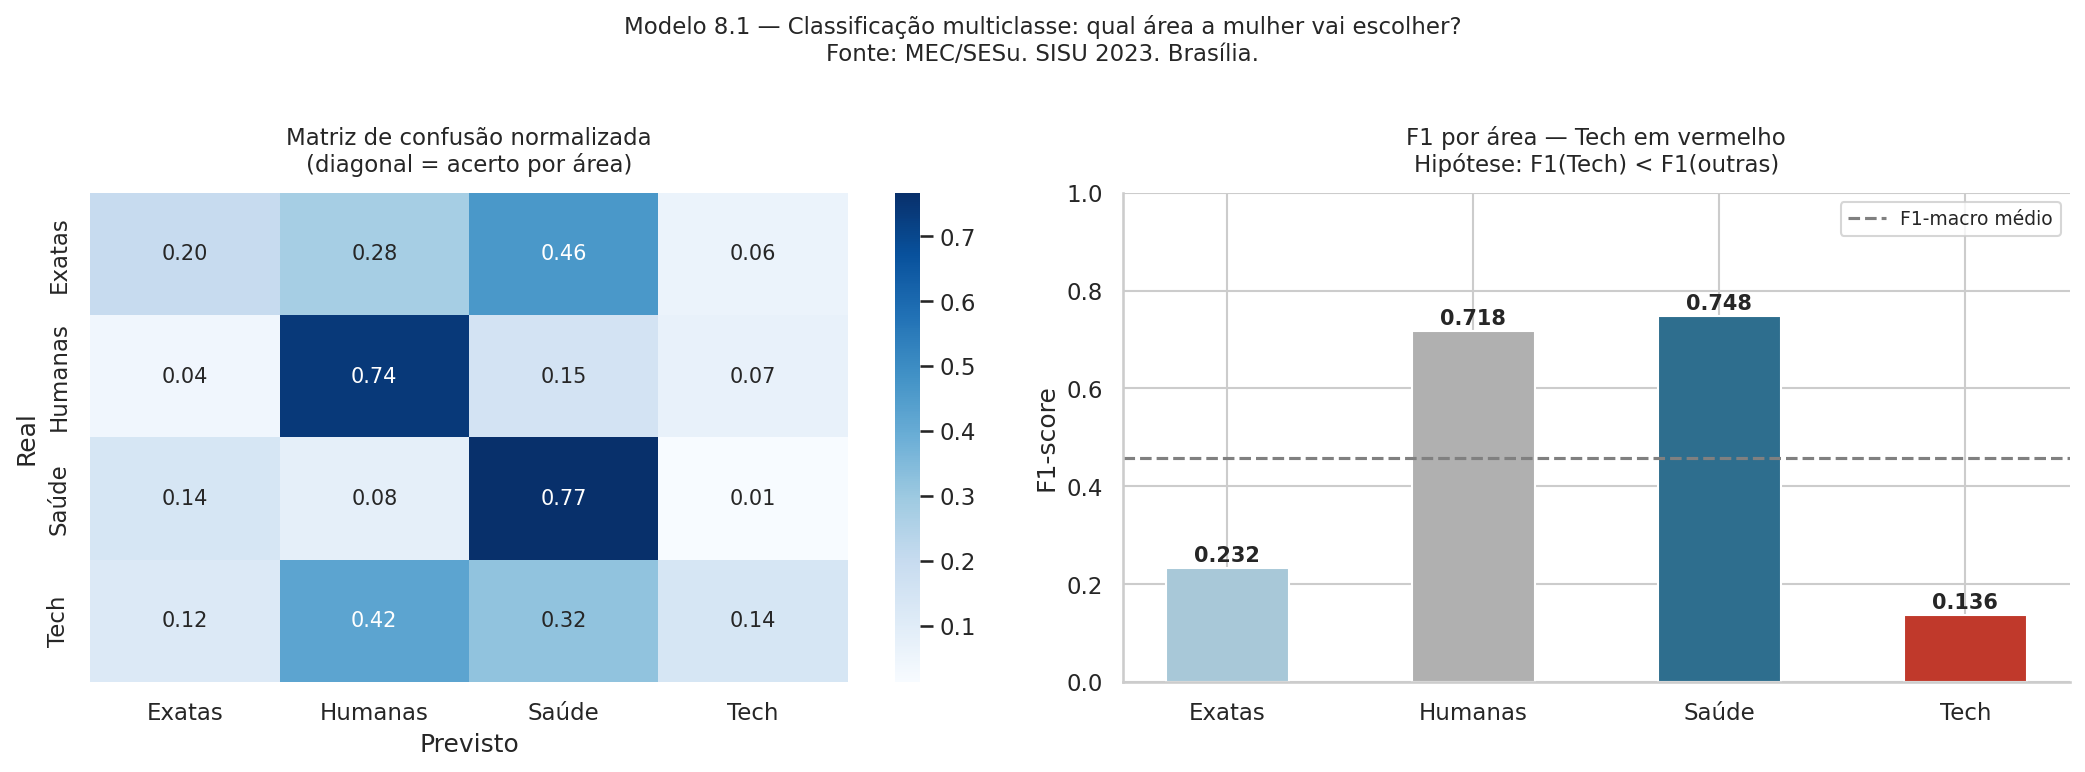

✅ Salvo: m81_multiclasse_areas.png
✅ modelo_multiclasse.pkl salvo

CONCLUSÃO:
  F1 Tech:          0.136
  F1 outras áreas:  0.566 (média)
  → CONFIRMADO: barreira específica de tech, não imprevisibilidade geral


In [ ]:
classes = rf_mc.classes_
f1s_mc  = f1_score(y_mc_test, y_mc_pred, average=None, labels=classes, zero_division=0)

print('=== F1 por área ===')
for cls, score in sorted(zip(classes, f1s_mc), key=lambda x: -x[1]):
    print(f'  {cls:15s}: F1={score:.3f}')
print(f'\n  F1-macro:    {f1_score(y_mc_test, y_mc_pred, average="macro", zero_division=0):.3f}')
print(f'  F1-weighted: {f1_score(y_mc_test, y_mc_pred, average="weighted", zero_division=0):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
ax = axes[0]
cm = confusion_matrix(y_mc_test, y_mc_pred, labels=classes, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusão normalizada\n(diagonal = acerto por área)',
             fontsize=11, pad=10)

# F1 por área
ax2 = axes[1]
cores_mc = {'Tech':COR_NEG,'Saúde':COR_FEM,'Exatas':COR_BRANCA,'Humanas':COR_MASC}
bars_mc = ax2.bar(classes, f1s_mc,
                   color=[cores_mc.get(c,'#888888') for c in classes],
                   edgecolor='white', width=0.5)
ax2.axhline(f1_score(y_mc_test, y_mc_pred, average='macro', zero_division=0),
            color='gray', linestyle='--', lw=1.5, label='F1-macro médio')
for bar, val in zip(bars_mc, f1s_mc):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0,1)
ax2.set_title('F1 por área — Tech em vermelho\n'
              'Hipótese: F1(Tech) < F1(outras)', fontsize=11, pad=10)
ax2.legend(fontsize=9)

plt.suptitle('Modelo 8.1 — Classificação multiclasse: qual área a mulher vai escolher?\n'
             + FONTE_SISU, fontsize=11, y=1.02)
save_fig('m81_multiclasse_areas.png')

# Exportar modelo para TechEquity app
import joblib
joblib.dump({'modelo':rf_mc,'colunas':X_mc.columns.tolist()}, 'modelo_multiclasse.pkl')
print('✅ modelo_multiclasse.pkl salvo')

f1_tech   = f1s_mc[list(classes).index('Tech')] if 'Tech' in classes else 0
f1_outras = np.mean([s for c,s in zip(classes, f1s_mc) if c != 'Tech'])
print(f'\nCONCLUSÃO:')
print(f'  F1 Tech:          {f1_tech:.3f}')
print(f'  F1 outras áreas:  {f1_outras:.3f} (média)')
if f1_tech < f1_outras - 0.05:
    print('  → CONFIRMADO: barreira específica de tech, não imprevisibilidade geral')
else:
    print('  → Modelo falha igualmente — revisar dados ou hipótese')


### 8.2 — Modelo 1 por subgrupo racial (Modelo 7.2 do TCC)

In [ ]:
# BASE: df_enem (2021–2023)
FEATURES_M72 = ['NEGRA','RENDA_NUM','ESCOL_MAX_PAIS','ESCOLA_PUBLICA',
                'REGIAO','OCUP_PAI','OCUP_MAE']
TARGET = 'NU_NOTA_MT'

subgrupos = {
    'Todas as mulheres': df_enem,
    'Brancas':           df_enem[df_enem['TP_COR_RACA'] == 1],
    'Negras (P+Pa)':     df_enem[df_enem['TP_COR_RACA'].isin([2,3])],
    'Pretas':            df_enem[df_enem['TP_COR_RACA'] == 2],
    'Pardas':            df_enem[df_enem['TP_COR_RACA'] == 3],
}

resultados_72 = {}
for nome, df_sub in subgrupos.items():
    feats = [f for f in FEATURES_M72
             if f != 'NEGRA' or nome == 'Todas as mulheres']
    df_s = df_sub[feats + [TARGET]].dropna()
    if len(df_s) < 1000:
        print(f'  {nome}: volume insuficiente ({len(df_s):,})'); continue
    df_enc_s = pd.get_dummies(df_s, columns=['REGIAO'], drop_first=True)
    X_s = df_enc_s.drop(TARGET, axis=1)
    y_s = df_enc_s[TARGET]
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
    sc = StandardScaler(); m = LinearRegression()
    m.fit(sc.fit_transform(X_tr), y_tr)
    y_hat = m.predict(sc.transform(X_te))
    coefs = pd.Series(m.coef_, index=X_s.columns)
    resultados_72[nome] = {'n':len(df_s),'R2':r2_score(y_te,y_hat),
                           'MAE':mean_absolute_error(y_te,y_hat),'coefs':coefs}
    print(f'  {nome:20s}: n={len(df_s):>7,} | R2={r2_score(y_te,y_hat):.3f} '
          f'| MAE={mean_absolute_error(y_te,y_hat):.1f} pts')


  Todas as mulheres   : n=985,906 | R2=0.257 | MAE=84.6 pts
  Brancas             : n=416,173 | R2=0.224 | MAE=90.9 pts
  Negras (P+Pa)       : n=531,346 | R2=0.150 | MAE=79.7 pts
  Pretas              : n=117,589 | R2=0.117 | MAE=74.4 pts
  Pardas              : n=413,757 | R2=0.164 | MAE=79.8 pts


=== Coeficientes padronizados por subgrupo racial ===
Variável             Todas as mulheres           Brancas     Negras (P+Pa)            Pretas            Pardas
--------------------------------------------------------------------------------------------------------------
RENDA_NUM                       +13.15            +15.36             +9.65             +7.72            +10.17
ESCOLA_PUBLICA                   -6.91             -7.08             -5.47             -4.76             -5.57
ESCOL_MAX_PAIS                  +10.71            +14.29             +8.63             +7.13             +9.03
OCUP_PAI                        +21.57            +24.20            +17.38            +15.08            +18.11
OCUP_MAE                        +20.29            +21.32            +16.88            +15.06            +17.17


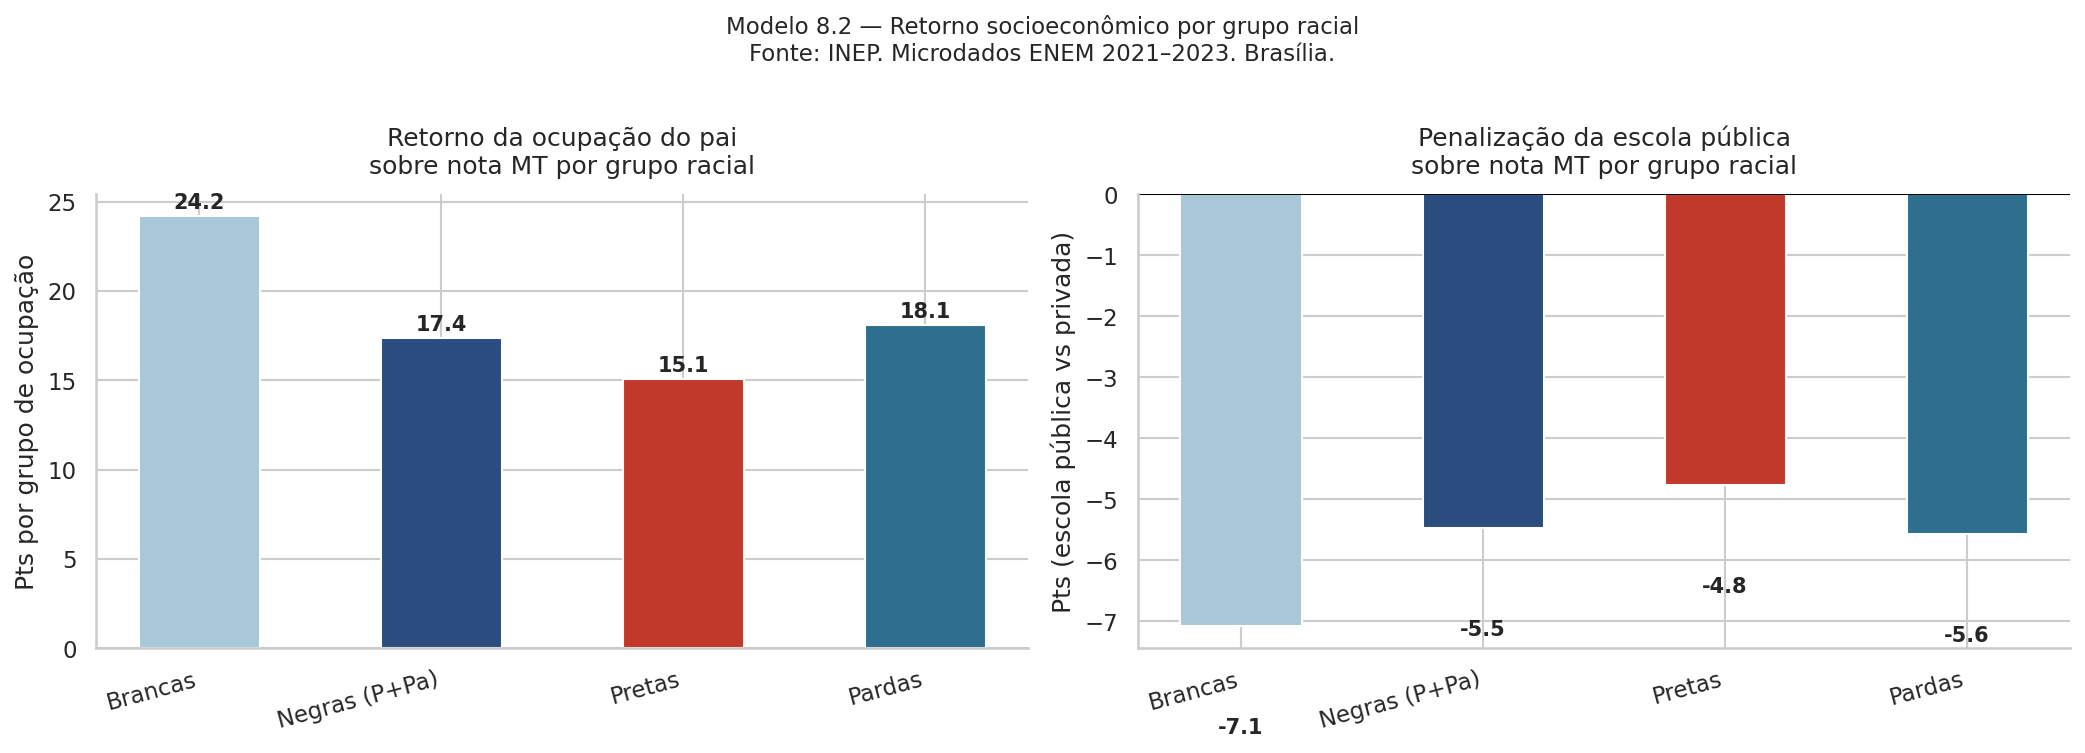

✅ Salvo: m82_coef_por_raca.png

=== Interpretação ===
  Retorno OCUP_PAI — Brancas: +24.20 pts/grupo
  Retorno OCUP_PAI — Negras:  +17.38 pts/grupo
  → Capital ocupacional rende 6.8 pts a mais para brancas

  R² Brancas: 0.224 | R² Negras: 0.150
  → Modelo explica 49% mais variância para brancas
     Fatores não observáveis pesam mais sobre negras


In [ ]:
vars_comparar = ['RENDA_NUM','ESCOLA_PUBLICA','ESCOL_MAX_PAIS','OCUP_PAI','OCUP_MAE']
print('=== Coeficientes padronizados por subgrupo racial ===')
print(f'{"Variável":20s}', end='')
for nome in resultados_72: print(f'{nome:>18s}', end='')
print()
print('-' * (20 + 18*len(resultados_72)))
for var in vars_comparar:
    print(f'{var:20s}', end='')
    for nome, res in resultados_72.items():
        val = res['coefs'].get(var, np.nan)
        print(f'{val:>+18.2f}' if pd.notna(val) else f'{"N/A":>18s}', end='')
    print()

grupos_plot    = [g for g in ['Brancas','Negras (P+Pa)','Pretas','Pardas'] if g in resultados_72]
cores_grupos72 = {'Brancas':COR_BRANCA,'Negras (P+Pa)':COR_NEGRA,
                  'Pretas':COR_NEG,'Pardas':COR_FEM}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, var, titulo, ylabel in [
    (axes[0], 'OCUP_PAI',
     'Retorno da ocupação do pai\nsobre nota MT por grupo racial',
     'Pts por grupo de ocupação'),
    (axes[1], 'ESCOLA_PUBLICA',
     'Penalização da escola pública\nsobre nota MT por grupo racial',
     'Pts (escola pública vs privada)'),
]:
    vals = [resultados_72[g]['coefs'].get(var, np.nan) for g in grupos_plot]
    bars_r = ax.bar(grupos_plot, vals,
                    color=[cores_grupos72[g] for g in grupos_plot],
                    edgecolor='white', width=0.5)
    for bar, val in zip(bars_r, vals):
        if pd.notna(val):
            ax.text(bar.get_x()+bar.get_width()/2,
                    val + 0.2 if val >= 0 else val - 1.5,
                    f'{val:.1f}', ha='center',
                    va='bottom' if val >= 0 else 'top',
                    fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_title(titulo, fontsize=12, pad=10)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xticklabels(grupos_plot, rotation=15, ha='right')

plt.suptitle('Modelo 8.2 — Retorno socioeconômico por grupo racial\n'
             + FONTE_ENEM, fontsize=11, y=1.02)
save_fig('m82_coef_por_raca.png')

if 'Brancas' in resultados_72 and 'Negras (P+Pa)' in resultados_72:
    ret_b = resultados_72['Brancas']['coefs'].get('OCUP_PAI', 0)
    ret_n = resultados_72['Negras (P+Pa)']['coefs'].get('OCUP_PAI', 0)
    print(f'\n=== Interpretação ===')
    print(f'  Retorno OCUP_PAI — Brancas: {ret_b:+.2f} pts/grupo')
    print(f'  Retorno OCUP_PAI — Negras:  {ret_n:+.2f} pts/grupo')
    if ret_b > ret_n + 1:
        print(f'  → Capital ocupacional rende {ret_b-ret_n:.1f} pts a mais para brancas')
    r2_b = resultados_72['Brancas']['R2']
    r2_n = resultados_72.get('Negras (P+Pa)',{}).get('R2', np.nan)
    print(f'\n  R² Brancas: {r2_b:.3f} | R² Negras: {r2_n:.3f}')
    if pd.notna(r2_n) and r2_b > r2_n + 0.02:
        print(f'  → Modelo explica {(r2_b/r2_n-1)*100:.0f}% mais variância para brancas')
        print(f'     Fatores não observáveis pesam mais sobre negras')


In [ ]:
from google.colab import files
import shutil, os

# Pasta de destino
RESULTADOS_DIR = '/content/resultados_tcc'
os.makedirs(RESULTADOS_DIR, exist_ok=True)

# Extensões a coletar
EXTENSOES = ('.png', '.pkl', '.xlsx', '.csv', '.txt')

# Coletar arquivos da raiz do /content (onde os gráficos foram salvos)
coletados = []
for f in os.listdir('/content'):
    if f.endswith(EXTENSOES):
        src = f'/content/{f}'
        shutil.copy(src, os.path.join(RESULTADOS_DIR, f))
        coletados.append(f)

print(f'{len(coletados)} arquivos coletados:')
for f in sorted(coletados):
    print(f'  {f}')

# Zipar tudo
shutil.make_archive('/content/resultados_tcc', 'zip', RESULTADOS_DIR)
print('\n✅ ZIP gerado: /content/resultados_tcc.zip')

# Baixar
files.download('/content/resultados_tcc.zip')

14 arquivos coletados:
  71_folga_nota.png
  72_gap_racial_areas.png
  74_evolucao_notas.png
  74_gap_tendencia.png
  achado_nota_nao_gargalo.png
  eda_escola_raca.png
  eda_raca_nota.png
  eda_renda_raca_nota.png
  eda_sisu_area.png
  m1_coef_socio_nota.png
  m2_roc_tech.png
  m81_multiclasse_areas.png
  m82_coef_por_raca.png
  modelo_multiclasse.pkl

✅ ZIP gerado: /content/resultados_tcc.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>